# Day 8 | Lab 8.2: Compliance Report Generator — Orchestrator-Worker + Evaluator-Optimizer + HITL

**Duration:** ~1.5 hours

**Scenario.** A regulatory compliance team at a mid-tier US bank generates quarterly reports for **FinCEN (BSA/AML)**, **OCC**, and a **State Banking Department** from raw transaction, customer, SAR-filing, and prior-finding data.

**Learning Objectives.** By the end of this lab, you will be able to:
1. Implement the **Orchestrator-Worker** pattern using LangGraph's `Send` API for dynamic parallel fan-out of report sections.
2. Build an **Evaluator-Optimizer** feedback loop with multi-check validation and a max-iteration cap.
3. Use **Parallelization** to fan out 5 specialist workers simultaneously and fan in their outputs with `Annotated[list, operator.add]` reducers.
4. Integrate **Human-in-the-Loop (HITL)** for compliance officer review using `interrupt()` and `Command(resume=...)`.
5. Apply **PII redaction** before any customer data reaches the LLM.
6. Generate **regulatory-grade reports** for three different regulators from a single graph.

**Tools.** LangGraph v1 (`Send`, `interrupt`, `Command`, `MemorySaver`) · LangChain v1 · OpenAI · `gpt-5-mini` (orchestrator/evaluator — reasoning) + `gpt-4.1-mini` (workers — speed/cost).

**API Verification.** This notebook is locked to LangGraph ≥ 1.0. The `interrupt()` and `Command()` APIs used here are the v1-stable signatures.

*Created by Prashant Sahu · [LinkedIn](https://www.linkedin.com/in/prashantksahu/)*

---


---

## Section 1: Environment Setup

Install the required packages. We need:
- **LangChain v1+** and **langchain-openai v1+** for LLM integration
- **LangGraph v1+** for the stateful multi-agent graph with `Send`, `interrupt`, and `MemorySaver`
- **pandas** for data analysis of CSV compliance data
- **pydantic** for structured output schemas

In [ ]:
# Required packages for this lab — already installed in your local venv.
# To install standalone, uncomment the line(s) below:
# !pip install -q 'langchain>=1.0' 'langchain-core>=1.0' 'langchain-openai>=1.0' 'langgraph>=1.0' pandas pydantic


---

## Section 1.5: API Key Configuration

The original notebook used Google Colab's `userdata`. Replaced with a local-venv pattern: load `.env` via `python-dotenv` if available, otherwise rely on env vars set in the shell or venv activation script.


In [ ]:
import os

# Local-venv pattern: load from .env if python-dotenv is available, otherwise rely on
# environment variables already set in your shell or venv activation script.
try:
    from dotenv import load_dotenv
    load_dotenv("..\\.env")
except ImportError:
    pass

for key in ['OPENAI_API_KEY']:
    status = '✅ Loaded' if os.environ.get(key) else '❌ MISSING'
    print(f'{key}: {status}')


In [ ]:
# ---- Standard library ----
import os
import json
import operator
import re
from datetime import datetime
from typing import TypedDict, Annotated, Literal
import time

# ---- Data processing ----
import pandas as pd

# ---- Pydantic (structured output) ----
from pydantic import BaseModel, Field

# ---- LangChain ----
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage

# ---- LangGraph ----
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send, interrupt, Command
from langgraph.checkpoint.memory import MemorySaver

# ---- API key from Colab Secrets ----

print("All imports successful.")
print(f"Notebook started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

---

## Section 2: Business Scenario --- MidwestBank Compliance Challenge

### The Institution

**MidwestBank** is a mid-size U.S. commercial bank headquartered in Kansas City, Missouri:
- **Total assets:** $8 billion
- **Employees:** 500 across 42 branches
- **Customers:** 5,000+ active accounts
- **Primary regulators:** FinCEN (BSA/AML), OCC (safety & soundness), State Banking Department

### The Problem: Quarterly Report Generation

MidwestBank's 6-person compliance team faces a recurring crisis every quarter:

| Pain Point | Current Reality |
|------------|----------------|
| **Manual data extraction** | Pull data from 5 separate systems (core banking, AML platform, KYC database, SAR system, risk engine) |
| **Report assembly time** | 4 full weeks per quarterly cycle for 3 different regulators |
| **Numerical errors** | 8-12 copy-paste errors per report (wrong totals, stale percentages) |
| **Terminology drift** | Inconsistent use of regulatory terms across sections (e.g., mixing "CDD" and "KYC" incorrectly) |
| **Cross-reference failures** | Section 2 may cite a number that contradicts Section 5 |
| **Regulatory risk** | Q2 2024 error triggered a formal inquiry, costing 200+ hours of remediation |

### The Solution: AI-Powered Compliance Report Generator

We will build a LangGraph-based system that:

1. **Reads** the regulator's template and dynamically plans which sections to generate
2. **Dispatches** 5 specialist workers (AML, KYC, SAR, Risk, Remediation) in **parallel**
3. **Evaluates** each section for numerical accuracy, terminology compliance, and cross-reference integrity
4. **Iterates** up to 3 times per section until quality passes all checks
5. **Pauses** for a compliance officer to review the final report before submission

### Expected Outcomes

| Metric | Before | After |
|--------|--------|-------|
| Report generation time | 4 weeks | 30 minutes |
| Numerical errors | 8-12 per report | 0 (evaluator-verified) |
| Terminology consistency | Manual spot-checks | 100% automated |
| Cross-reference integrity | Occasional failures | Guaranteed |
| Compliance officer time | 120 hours/quarter | 2 hours (review only) |

---

## Section 3: Load All Compliance Data

We load 8 data files that represent MidwestBank's compliance data ecosystem:

| File | Format | Records | Description |
|------|--------|---------|-------------|
| `customers.csv` | CSV | 5,000 | Customer master with KYC status, risk scores, PEP flags |
| `transactions.csv` | CSV | 50,000 | Transaction ledger with suspicious activity flags |
| `sar_filings.csv` | CSV | 250 | Suspicious Activity Reports filed with FinCEN |
| `prior_findings.csv` | CSV | 40 | Regulatory examination findings and remediation status |
| `regulatory_thresholds.json` | JSON | --- | BSA/AML thresholds (CTR $10K, SAR thresholds, KYC cycles) |
| `fincen_template.md` | Markdown | 10 sections | FinCEN quarterly BSA/AML report template |
| `occ_template.md` | Markdown | 10 parts | OCC examination report template |
| `state_template.md` | Markdown | 12 sections | State banking department report template |

In [3]:
# ---- Load CSV data files ----
customers_df = pd.read_csv("customers.csv")
transactions_df = pd.read_csv("transactions.csv")
sar_df = pd.read_csv("sar_filings.csv")
findings_df = pd.read_csv("prior_findings.csv")

# ---- Load JSON thresholds ----
with open("regulatory_thresholds.json") as f:
    thresholds = json.load(f)

# ---- Load report templates ----
with open("fincen_template.md") as f:
    fincen_template = f.read()

with open("occ_template.md") as f:
    occ_template = f.read()

with open("state_template.md") as f:
    state_template = f.read()

# ---- Store templates in a lookup dict ----
TEMPLATES = {
    "FinCEN": fincen_template,
    "OCC": occ_template,
    "State": state_template,
}

# ---- Print summary statistics ----
print("=" * 70)
print("MIDWESTBANK DATA SUMMARY")
print("=" * 70)
print(f"\nCustomers:     {len(customers_df):>8,} records  | Columns: {list(customers_df.columns)}")
print(f"Transactions:  {len(transactions_df):>8,} records  | Columns: {list(transactions_df.columns)}")
print(f"SAR Filings:   {len(sar_df):>8,} records  | Columns: {list(sar_df.columns)}")
print(f"Prior Findings:{len(findings_df):>8,} records  | Columns: {list(findings_df.columns)}")
print(f"\nRegulatory Thresholds: {len(thresholds)} top-level keys")
print(f"Templates loaded: {list(TEMPLATES.keys())}")
print(f"  - FinCEN: {len(fincen_template):,} chars")
print(f"  - OCC:    {len(occ_template):,} chars")
print(f"  - State:  {len(state_template):,} chars")

MIDWESTBANK DATA SUMMARY

Customers:        5,000 records  | Columns: ['customer_id', 'name', 'dob', 'nationality', 'risk_score', 'kyc_status', 'kyc_last_verified', 'account_type', 'pep_flag']
Transactions:    50,000 records  | Columns: ['txn_id', 'date', 'sender_account', 'receiver_account', 'amount', 'currency', 'txn_type', 'is_suspicious', 'SAR_filed']
SAR Filings:        250 records  | Columns: ['sar_id', 'customer_id', 'filing_date', 'suspicious_activity_type', 'amount_involved', 'narrative', 'status']
Prior Findings:      40 records  | Columns: ['finding_id', 'regulator', 'finding_date', 'category', 'severity', 'description', 'remediation_status', 'remediation_deadline']

Regulatory Thresholds: 11 top-level keys
Templates loaded: ['FinCEN', 'OCC', 'State']
  - FinCEN: 5,406 chars
  - OCC:    5,530 chars
  - State:  6,769 chars


In [4]:
# ---- Quick look at sample rows from each dataset ----
print("--- Customers (first 3 rows) ---")
display(customers_df.head(3))

print("\n--- Transactions (first 3 rows) ---")
display(transactions_df.head(3))

print("\n--- SAR Filings (first 3 rows) ---")
display(sar_df.head(3))

print("\n--- Prior Findings (first 3 rows) ---")
display(findings_df.head(3))

--- Customers (first 3 rows) ---


,customer_id,name,dob,nationality,risk_score,kyc_status,kyc_last_verified,account_type,pep_flag
0,CUST-000001,Christopher Brown,2006-11-13,US,low,expired,2024-09-16,checking,False
1,CUST-000002,Mary Smith,2002-12-13,US,medium,verified,2024-06-01,investment,False
2,CUST-000003,Charles Rodriguez,1957-04-11,US,low,verified,2025-08-20,business,False



--- Transactions (first 3 rows) ---


,txn_id,date,sender_account,receiver_account,amount,currency,txn_type,is_suspicious,SAR_filed
0,TXN-00000001,2025-05-05,CUST-000913,CUST-000205,1232.01,USD,ATM,False,False
1,TXN-00000002,2025-06-22,CUST-000713,CUST-004838,158.69,USD,withdrawal,False,False
2,TXN-00000003,2026-03-15,CUST-004598,CUST-001629,3509.61,USD,withdrawal,False,False



--- SAR Filings (first 3 rows) ---


,sar_id,customer_id,filing_date,suspicious_activity_type,amount_involved,narrative,status
0,SAR-0001,CUST-000913,2026-03-16,Rapid movement of funds,252442.94,Suspicious activity detected: Rapid movement o...,closed
1,SAR-0002,CUST-000840,2025-04-16,Trade-based money laundering,96069.44,Alert generated for trade-based money launderi...,filed
2,SAR-0003,CUST-000245,2026-02-09,Round dollar amounts,240334.28,Customer CUST-000245 engaged in round dollar a...,closed



--- Prior Findings (first 3 rows) ---


,finding_id,regulator,finding_date,category,severity,description,remediation_status,remediation_deadline
0,FIND-0001,State Banking Dept,2025-07-13,AML/BSA,significant,AML policy not updated to reflect regulatory c...,in_progress,2025-10-08
1,FIND-0002,FinCEN,2025-08-01,Customer Due Diligence,significant,CDD procedures not commensurate with customer ...,overdue,2025-09-08
2,FIND-0003,FinCEN,2025-08-19,KYC,minor,KYC verification procedures not consistently a...,in_progress,2026-02-04


---

## Section 4: Data Analysis Helpers --- Pre-Compute Key Statistics

Before any data reaches the LLM, we pre-compute all the statistics that workers will cite in their report sections. This serves two critical purposes:

1. **Accuracy:** Workers reference verified numbers from `DATA_SUMMARY` rather than hallucinating statistics
2. **PII protection:** Only aggregate statistics are passed to the LLM --- never raw customer records

The evaluator will later validate that every number in a drafted section matches `DATA_SUMMARY`.

In [5]:
# =====================================================================
# PRE-COMPUTE ALL STATISTICS THAT WORKERS WILL NEED
# =====================================================================

# ---- AML / Transaction Monitoring Statistics ----
total_txn_count = int(len(transactions_df))
total_txn_amount = float(transactions_df["amount"].sum())
suspicious_txns = transactions_df[transactions_df["is_suspicious"] == True]
suspicious_count = int(len(suspicious_txns))
suspicious_pct = float(round(suspicious_count / total_txn_count * 100, 2))
suspicious_amount = float(suspicious_txns["amount"].sum())

# Transactions above CTR threshold ($10,000)
ctr_threshold = float(thresholds["ctr_threshold"]["amount"])
ctr_eligible = transactions_df[transactions_df["amount"] >= ctr_threshold]
ctr_count = int(len(ctr_eligible))

# Transaction types breakdown
txn_type_counts = {str(k): int(v) for k, v in transactions_df["txn_type"].value_counts().to_dict().items()}

# ---- SAR Filing Statistics ----
sar_total = int(len(sar_df))
sar_total_amount = float(sar_df["amount_involved"].sum())
sar_by_type = {str(k): int(v) for k, v in sar_df["suspicious_activity_type"].value_counts().to_dict().items()}
sar_by_status = {str(k): int(v) for k, v in sar_df["status"].value_counts().to_dict().items()}

# ---- KYC / CDD Statistics ----
kyc_status_dist = {str(k): int(v) for k, v in customers_df["kyc_status"].value_counts().to_dict().items()}
kyc_verified_count = int(kyc_status_dist.get("verified", 0))
kyc_verified_pct = float(round(kyc_verified_count / len(customers_df) * 100, 2))
kyc_expired_count = int(kyc_status_dist.get("expired", 0))
kyc_pending_count = int(kyc_status_dist.get("pending", 0))

# PEP (Politically Exposed Person) statistics
pep_count = int(customers_df[customers_df["pep_flag"] == True].shape[0])

# ---- Risk Score Distribution ----
risk_dist = {str(k): int(v) for k, v in customers_df["risk_score"].value_counts().to_dict().items()}
high_risk_count = int(risk_dist.get("high", 0))
medium_risk_count = int(risk_dist.get("medium", 0))
low_risk_count = int(risk_dist.get("low", 0))

# ---- Account Type Distribution ----
account_type_dist = {str(k): int(v) for k, v in customers_df["account_type"].value_counts().to_dict().items()}

# ---- Prior Findings / Remediation Statistics ----
findings_total = int(len(findings_df))
findings_by_category = {str(k): int(v) for k, v in findings_df["category"].value_counts().to_dict().items()}
findings_by_severity = {str(k): int(v) for k, v in findings_df["severity"].value_counts().to_dict().items()}
findings_by_status = {str(k): int(v) for k, v in findings_df["remediation_status"].value_counts().to_dict().items()}
findings_by_regulator = {str(k): int(v) for k, v in findings_df["regulator"].value_counts().to_dict().items()}

# Overdue remediations
overdue_findings = findings_df[findings_df["remediation_status"] == "overdue"]
overdue_count = int(len(overdue_findings))

# =====================================================================
# ASSEMBLE INTO A SINGLE DATA_SUMMARY DICTIONARY
# =====================================================================

DATA_SUMMARY = {
    "institution": {
        "name": "MidwestBank",
        "total_assets": "$8 billion",
        "employees": 500,
        "branches": 42,
    },
    "aml_monitoring": {
        "total_transactions": total_txn_count,
        "total_transaction_amount": float(round(total_txn_amount, 2)),
        "suspicious_transactions": suspicious_count,
        "suspicious_percentage": suspicious_pct,
        "suspicious_amount": float(round(suspicious_amount, 2)),
        "ctr_eligible_transactions": ctr_count,
        "ctr_threshold": ctr_threshold,
        "transaction_types": txn_type_counts,
    },
    "sar_filings": {
        "total_sars": sar_total,
        "total_amount_involved": float(round(sar_total_amount, 2)),
        "by_activity_type": sar_by_type,
        "by_status": sar_by_status,
    },
    "kyc_cdd": {
        "total_customers": int(len(customers_df)),
        "kyc_verified": kyc_verified_count,
        "kyc_verified_pct": kyc_verified_pct,
        "kyc_expired": kyc_expired_count,
        "kyc_pending": kyc_pending_count,
        "kyc_status_distribution": kyc_status_dist,
        "pep_customers": pep_count,
        "account_types": account_type_dist,
    },
    "risk_assessment": {
        "high_risk": high_risk_count,
        "medium_risk": medium_risk_count,
        "low_risk": low_risk_count,
        "risk_distribution": risk_dist,
    },
    "remediation": {
        "total_findings": findings_total,
        "by_category": findings_by_category,
        "by_severity": findings_by_severity,
        "by_status": findings_by_status,
        "by_regulator": findings_by_regulator,
        "overdue_count": overdue_count,
        "overdue_details": overdue_findings[["finding_id", "category", "severity", "remediation_deadline"]].to_dict(orient="records") if overdue_count > 0 else [],
    },
}

# ---- Print the summary for verification ----
print("=" * 70)
print("DATA_SUMMARY (passed to workers --- NO PII, only aggregates)")
print("=" * 70)
for section, stats in DATA_SUMMARY.items():
    print(f"\n>> {section.upper()}")
    for key, val in stats.items():
        print(f"   {key}: {val}")


DATA_SUMMARY (passed to workers --- NO PII, only aggregates)

>> INSTITUTION
   name: MidwestBank
   total_assets: $8 billion
   employees: 500
   branches: 42

>> AML_MONITORING
   total_transactions: 50000
   total_transaction_amount: 311260070.15
   suspicious_transactions: 1053
   suspicious_percentage: 2.11
   suspicious_amount: 5214006.53
   ctr_eligible_transactions: 4347
   ctr_threshold: 10000.0
   transaction_types: {'transfer': 8578, 'deposit': 8449, 'ATM': 8361, 'check': 8332, 'withdrawal': 8211, 'wire': 8069}

>> SAR_FILINGS
   total_sars: 250
   total_amount_involved: 123064246.65
   by_activity_type: {'Round dollar amounts': 28, 'Currency exchange patterns': 27, 'Unusual wire transfer pattern': 27, 'Rapid movement of funds': 26, 'Trade-based money laundering': 26, 'Large cash deposits': 25, 'Structuring (smurfing)': 24, 'Shell company indicators': 24, 'High-risk jurisdiction transfer': 23, 'Inconsistent with customer profile': 20}
   by_status: {'under_review': 85, 'file

---

## Section 5: PII Redaction Layer

**Critical for banking compliance:** No customer Personally Identifiable Information (PII) should ever reach the LLM. Our workers operate exclusively on the pre-computed `DATA_SUMMARY` (aggregates only), but we add a defense-in-depth redaction layer as a safety net.

This function scans any text for patterns that look like customer IDs or names and replaces them with generic tokens.

In [6]:
def redact_pii(text: str) -> str:
    """
    Defense-in-depth PII redaction. Removes customer IDs and names
    from any text before it is sent to the LLM.

    Patterns redacted:
    - Customer IDs (CUST-XXXXXX)
    - SAR IDs are kept (SAR-XXXX) because they are filing identifiers, not PII
    - Names matching the customer database
    """
    # Redact customer IDs
    text = re.sub(r"CUST-\d{6}", "[REDACTED-CUSTOMER-ID]", text)

    # Redact any customer names from the database
    # Build a set of all names for fast lookup
    all_names = set(customers_df["name"].dropna().unique())
    for name in all_names:
        if name in text:
            text = text.replace(name, "[REDACTED-NAME]")

    return text


# ---- Quick test ----
test_text = "Customer CUST-000001 (Christopher Brown) made a suspicious transfer."
print(f"Before: {test_text}")
print(f"After:  {redact_pii(test_text)}")

Before: Customer CUST-000001 (Christopher Brown) made a suspicious transfer.
After:  Customer [REDACTED-CUSTOMER-ID] ([REDACTED-NAME]) made a suspicious transfer.


---

## Section 6: State Definitions

This system uses **two separate state schemas** --- a critical architectural decision that enables the `Send` API pattern.

### Why Two States?

| State | Who Uses It | Purpose |
|-------|-------------|--------|
| `ComplianceReportState` | Orchestrator, Evaluator, Synthesizer, HITL | The **main graph state** --- tracks the full report lifecycle |
| `WorkerState` | Section workers (via `Send()`) | The **per-worker state** --- each `Send()` call creates an independent instance |

The key insight is the **`Annotated[list, operator.add]` reducer**. When multiple workers run in parallel, each returns `{"section_drafts": [their_draft]}`. The `operator.add` reducer **automatically concatenates** these lists into the main state. Without this reducer, the last worker to finish would overwrite all previous results.

```
Worker 1 returns: {"section_drafts": [draft_A]}
Worker 2 returns: {"section_drafts": [draft_B]}     --> Reducer combines: [draft_A, draft_B, draft_C]
Worker 3 returns: {"section_drafts": [draft_C]}
```

In [ ]:
# =====================================================================
# MAIN GRAPH STATE --- used by orchestrator, evaluator, synthesizer
# =====================================================================
# =====================================================================


def merge_drafts_by_name(existing: list, new: list) -> list:
    """Upsert reducer keyed on `section_name`.

    - Fan-in from parallel workers: each Send returns `{"section_drafts": [one_draft]}`.
      This reducer is called once per return; drafts accumulate by unique name.
    - Revision: the revision node returns the corrected versions of failed
      drafts. This reducer overwrites the old draft with the new one, rather
      than appending a duplicate.
    - Evaluator approvals: same pattern for `approved_sections` prevents
      duplicates when a section is seen more than once.
    """
    if not isinstance(existing, list):
        existing = []
    if not isinstance(new, list):
        new = []
    by_name = {d["section_name"]: d for d in existing}
    for d in new:
        by_name[d["section_name"]] = d
    return list(by_name.values())


class ComplianceReportState(TypedDict):
    """Main graph state for the compliance report generator."""
    # ---- Input parameters ----
    regulator: str                                  # 'FinCEN', 'OCC', or 'State'
    quarter: str                                    # e.g., 'Q4 2025'
    template: str                                   # The loaded template text

    # ---- Orchestrator output ----
    section_plan: list                              # List of SectionAssignment dicts

    # ---- Worker output (REDUCER: upsert by section_name) ----
    section_drafts: Annotated[list, merge_drafts_by_name]

    # ---- Evaluator state (replaced each iteration) ----
    evaluation_results: list
    sections_needing_revision: list
    iteration_count: int

    # ---- Approved sections (REDUCER: upsert by section_name) ----
    approved_sections: Annotated[list, merge_drafts_by_name]

    # ---- Synthesis output ----
    executive_summary: str
    full_report: str

    # ---- HITL state ----
    compliance_officer_notes: str
    hitl_approved: bool

    # ---- HITL acknowledgments (new) ----
    acknowledged_warnings: list
    unresolved_sections: list

    # ---- Final output ----
    final_report: str


# =====================================================================
# WORKER STATE --- each Send() creates one independent instance
# =====================================================================

class WorkerState(TypedDict):
    """Per-worker state created by each Send() invocation."""
    section: dict
    data_summary: dict
    thresholds: dict
    section_drafts: Annotated[list, merge_drafts_by_name]


print("State definitions created (with keyed-merge reducer).")
print(f"  ComplianceReportState fields: {list(ComplianceReportState.__annotations__.keys())}")
print(f"  WorkerState fields:           {list(WorkerState.__annotations__.keys())}")


State definitions created (with keyed-merge reducer).
  ComplianceReportState fields: ['regulator', 'quarter', 'template', 'section_plan', 'section_drafts', 'evaluation_results', 'sections_needing_revision', 'iteration_count', 'approved_sections', 'executive_summary', 'full_report', 'compliance_officer_notes', 'hitl_approved', 'acknowledged_warnings', 'unresolved_sections', 'final_report']
  WorkerState fields:           ['section', 'data_summary', 'thresholds', 'section_drafts']


---

## Section 7: Pydantic Models for Structured Output

We define strict schemas that the LLM must conform to. This eliminates parsing errors and gives us type-safe access to planned sections, drafted content, and evaluation results.

### Key Regulatory Terms Used in the Models

| Term | Full Name | Regulation |
|------|-----------|------------|
| **BSA** | Bank Secrecy Act | 31 USC 5311 |
| **AML** | Anti-Money Laundering | 31 CFR Part 1020 |
| **SAR** | Suspicious Activity Report | 31 CFR 1020.320 |
| **CTR** | Currency Transaction Report | 31 CFR 1010.310 |
| **KYC** | Know Your Customer | Part of CDD rule |
| **CDD** | Customer Due Diligence | 31 CFR 1010.230 |
| **PEP** | Politically Exposed Person | FATF Recommendation 12 |
| **EDD** | Enhanced Due Diligence | Required for high-risk customers |

In [8]:
# =====================================================================
# PYDANTIC MODELS FOR STRUCTURED LLM OUTPUT
# =====================================================================

class SectionAssignment(BaseModel):
    """An individual section that the orchestrator assigns to a worker."""
    section_name: str = Field(description="The section title as it appears in the template")
    description: str = Field(description="What this section should cover")
    data_sources: list[str] = Field(description="Which data categories to reference: aml_monitoring, sar_filings, kyc_cdd, risk_assessment, remediation")
    worker_type: Literal["aml", "kyc", "sar", "risk", "remediation"] = Field(
        description="The specialist worker type to handle this section"
    )
    regulatory_reference: str = Field(description="The primary regulatory citation, e.g., '31 CFR 1020.320'")


class SectionPlan(BaseModel):
    """The orchestrator's full plan for the report."""
    regulator: str = Field(description="The target regulator: FinCEN, OCC, or State")
    quarter: str = Field(description="The reporting period, e.g., Q4 2025")
    sections: list[SectionAssignment] = Field(description="Ordered list of section assignments")


class SectionDraft(BaseModel):
    """A completed section draft from a worker."""
    section_name: str = Field(description="The section title")
    content: str = Field(description="The drafted narrative with filled-in data")
    key_metrics: dict[str, float] = Field(default_factory=dict, description="All numbers cited in the narrative, as key-value pairs")
    data_citations: list[str] = Field(description="Which data categories were used")
    confidence: float = Field(description="Worker's confidence in the draft, 0.0 to 1.0")


class EvaluationResult(BaseModel):
    """Evaluation of a single section draft."""
    section_name: str = Field(description="The section being evaluated")
    numerical_accuracy: bool = Field(description="Are all cited numbers correct per DATA_SUMMARY?")
    terminology_compliance: bool = Field(description="Are regulatory terms used correctly and consistently?")
    cross_reference_integrity: bool = Field(description="Do cross-references to other sections check out?")
    overall_pass: bool = Field(description="True only if ALL three checks pass")
    feedback: str = Field(description="Specific improvement instructions if any check failed; empty string if all passed")


print("Pydantic models defined:")
print(f"  SectionAssignment fields: {list(SectionAssignment.model_fields.keys())}")
print(f"  SectionPlan fields:       {list(SectionPlan.model_fields.keys())}")
print(f"  SectionDraft fields:      {list(SectionDraft.model_fields.keys())}")
print(f"  EvaluationResult fields:  {list(EvaluationResult.model_fields.keys())}")

Pydantic models defined:
  SectionAssignment fields: ['section_name', 'description', 'data_sources', 'worker_type', 'regulatory_reference']
  SectionPlan fields:       ['regulator', 'quarter', 'sections']
  SectionDraft fields:      ['section_name', 'content', 'key_metrics', 'data_citations', 'confidence']
  EvaluationResult fields:  ['section_name', 'numerical_accuracy', 'terminology_compliance', 'cross_reference_integrity', 'overall_pass', 'feedback']


---

## Section 8: LLM Initialization

We configure **four LLM instances**, each optimized for its role:

| Instance | Model | Temperature | Role |
|----------|-------|-------------|------|
| `llm_orchestrator` | gpt-5-mini | default | Strategic planning --- which sections, which workers |
| `llm_worker` | gpt-4.1-mini | 0.2 | Report writing --- needs natural prose with slight variation |
| `llm_evaluator` | gpt-5-mini | default | Validation --- deterministic accuracy checking |
| `llm_synthesis` | gpt-4.1-mini | 0.3 | Executive summary --- slightly more creative latitude |

**Why different models?** Reasoning models (`gpt-5-mini`) excel at planning and evaluation but are more expensive. Writing models (`gpt-4.1-mini`) are cost-effective for generating narrative prose and benefit from a small temperature to introduce natural variation while remaining factual.

In [9]:
# ---- Orchestrator: reasoning model for strategic planning ----
llm_orchestrator = ChatOpenAI(model="gpt-5-mini")

# ---- Workers: writing model with slight temperature for natural prose ----
llm_worker = ChatOpenAI(model="gpt-4.1-mini", temperature=0.2)

# ---- Evaluator: reasoning model for deterministic assessment ----
llm_evaluator = ChatOpenAI(model="gpt-5-mini")

# ---- Synthesizer: writing model with slightly more creative latitude ----
llm_synthesis = ChatOpenAI(model="gpt-4.1-mini", temperature=0.3)

print("LLM instances initialized:")
print(f"  Orchestrator: {llm_orchestrator.model_name}")
print(f"  Worker:       {llm_worker.model_name} (temp={llm_worker.temperature})")
print(f"  Evaluator:    {llm_evaluator.model_name}")
print(f"  Synthesizer:  {llm_synthesis.model_name} (temp={llm_synthesis.temperature})")

LLM instances initialized:
  Orchestrator: gpt-5-mini
  Worker:       gpt-4.1-mini (temp=0.2)
  Evaluator:    gpt-5-mini
  Synthesizer:  gpt-4.1-mini (temp=0.3)


---

## Section 9: Orchestrator Node

The orchestrator is the brain of the system. Given a regulator template, it:

1. **Reads** the template text and identifies all sections requiring data
2. **Maps** each section to the appropriate specialist worker (AML, KYC, SAR, Risk, Remediation)
3. **Plans** the data sources each worker needs
4. **Returns** a structured `SectionPlan` with ordered assignments

This is the **Orchestrator-Worker pattern (Pattern #4)** --- the orchestrator does not write any sections itself; it only plans and delegates.

In [ ]:
def orchestrator_node(state: ComplianceReportState) -> dict:
    """Orchestrator: reads the template and creates a section-by-section work plan.
    """
    print(f"\n{'='*60}")
    print(f"ORCHESTRATOR: Planning {state['regulator']} report for {state['quarter']}")
    print(f"{'='*60}")

    template = state["template"]
    regulator = state["regulator"]
    quarter = state["quarter"]
    available_data = list(DATA_SUMMARY.keys())

    messages = [
        SystemMessage(content="""You are a banking compliance report planner. Your job is to read a
regulatory report template and create a detailed work plan that assigns each section to a specialist worker.

WORKER TYPES and their specializations:
- "aml": Anti-Money Laundering transaction monitoring, alerts, CTR filings, system performance
- "kyc": Know Your Customer, Customer Due Diligence (CDD), Enhanced Due Diligence (EDD), beneficial ownership
- "sar": Suspicious Activity Reporting, SAR filings, timeliness, narrative quality
- "risk": Risk assessment, risk ratings, high-risk customer monitoring, enterprise risk
- "remediation": Prior findings, corrective actions, overdue items, audit results

RULES:
1. Every data-bearing section in the template MUST be assigned to exactly one worker.
2. Sections that are purely structural (title page, certification, appendices) should be EXCLUDED.
3. Each assignment must include the primary regulatory citation.
4. Map data_sources to the categories available in our DATA_SUMMARY.

*** CRITICAL GRANULARITY RULE ***
5. Pick ONE level of decomposition per topic --- either the PARENT section OR its subsections, NEVER BOTH.
6. Target 8-15 total sections for a typical quarterly template.

*** CRITICAL EXCLUSION RULE (new) ***
7. DO NOT include the Executive Summary or Management Summary as a worker assignment.
   The synthesizer generates the executive summary after all sections are complete,
   using the assembled content plus DATA_SUMMARY. Listing it as a worker section
   creates a duplicate at the top of the final report.
   If the template has a section titled "Executive Summary", "Management Summary",
   or similar, SKIP it in your plan.
"""),
        HumanMessage(content=f"""Create a section plan for the {regulator} quarterly compliance report
for {quarter}.

TEMPLATE:
{template}

AVAILABLE DATA CATEGORIES: {available_data}

Return a SectionPlan with all data-bearing sections assigned to workers.
Remember: ONE level of granularity per topic. SKIP any executive/management summary section.
Target 8-15 sections total.""")
    ]

    structured_llm = llm_orchestrator.with_structured_output(SectionPlan)
    plan = structured_llm.invoke(messages)

    # Defensive filter: drop any executive/management summary the LLM still included.
    SUMMARY_NAMES = ("executive summary", "management summary")
    filtered = [s for s in plan.sections
                if not any(kw in s.section_name.lower() for kw in SUMMARY_NAMES)]
    if len(filtered) < len(plan.sections):
        dropped = [s.section_name for s in plan.sections if s not in filtered]
        print(f"  (Filtered out summary sections from plan: {dropped})")

    print(f"\nPlanned {len(filtered)} sections:")
    for i, section in enumerate(filtered, 1):
        print(f"  {i}. [{section.worker_type.upper()}] {section.section_name}")
        print(f"     Data: {section.data_sources} | Ref: {section.regulatory_reference}")

    return {
        "section_plan": [s.model_dump() for s in filtered],
    }


print("Orchestrator node defined (excludes exec/management summary from plan).")


Orchestrator node defined (excludes exec/management summary from plan).


---

## Section 10: Fan-Out with the Send API

This is the **most important pattern** in this lab. The `Send` API creates **independent, parallel worker instances** --- one for each section in the orchestrator's plan.

### How `Send` Works

```python
Send("node_name", state_for_that_node)
```

- `"node_name"` is the target node (our `section_worker`)
- `state_for_that_node` is a **fresh `WorkerState`** with just that section's assignment
- LangGraph creates N parallel instances of `section_worker`, one per `Send`
- All N workers run concurrently and their outputs merge via the `operator.add` reducer

### Fan-Out / Fan-In Flow

```
Orchestrator plans 5 sections
    |
    +-- Send("section_worker", {section: AML_section, ...})
    +-- Send("section_worker", {section: KYC_section, ...})
    +-- Send("section_worker", {section: SAR_section, ...})      All run in PARALLEL
    +-- Send("section_worker", {section: Risk_section, ...})
    +-- Send("section_worker", {section: Remediation_section, ...})
    |
    v
section_drafts = [draft_AML, draft_KYC, draft_SAR, draft_Risk, draft_Remediation]  <-- Reducer merges
```

In [11]:
def assign_workers(state: ComplianceReportState) -> list[Send]:
    """Fan-out function: creates a parallel Send() for each planned section.

    This is a CONDITIONAL EDGE function. Instead of returning a string
    (like a normal conditional edge), it returns a list of Send objects.
    LangGraph treats each Send as an independent worker invocation.
    """
    sends = []
    for section in state["section_plan"]:
        sends.append(
            Send("section_worker", {
                "section": section,
                "data_summary": DATA_SUMMARY,
                "thresholds": thresholds,
            })
        )

    print(f"\nFAN-OUT: Dispatching {len(sends)} parallel workers...")
    for s in sends:
        print(f"  -> Worker for: {s.arg['section']['section_name']} [{s.arg['section']['worker_type']}]")

    return sends


print("Fan-out function defined.")

Fan-out function defined.


---

## Section 11: Section Worker Node

A **universal worker** that handles all 5 specialist types (AML, KYC, SAR, Risk, Remediation). Rather than writing 5 separate worker functions, we use a single worker that adapts its behavior based on the `worker_type` field in its assignment.

Each worker:
1. Reads its section assignment from `WorkerState`
2. Pulls the relevant subset of `DATA_SUMMARY` based on `data_sources`
3. Crafts a detailed prompt with the actual numbers
4. Uses `gpt-4.1-mini` (temp=0.2) to draft the section narrative
5. Returns `{"section_drafts": [draft]}` which the reducer appends to the main state

In [ ]:
# Worker-type-specific system prompts
WORKER_PROMPTS = {
    "aml": """You are an AML (Anti-Money Laundering) compliance report writer for a mid-size U.S. bank.
Your expertise covers BSA transaction monitoring systems, alert management, Currency Transaction Reports (CTRs),
and AML program effectiveness. Use precise regulatory terminology per 31 CFR Part 1020.
Always cite exact numbers from the provided data. Never invent statistics.""",

    "kyc": """You are a KYC/CDD (Know Your Customer / Customer Due Diligence) compliance report writer.
Your expertise covers customer identification programs (CIP), KYC verification, beneficial ownership
requirements (31 CFR 1010.230), Enhanced Due Diligence (EDD) for high-risk customers, and PEP screening.
Always cite exact numbers from the provided data. Never invent statistics.""",

    "sar": """You are a SAR (Suspicious Activity Report) compliance report writer.
Your expertise covers SAR filing requirements (31 CFR 1020.320), suspicious activity detection,
SAR timeliness requirements (30-day initial, 60-day maximum), narrative quality standards,
and FinCEN filing procedures. Always cite exact numbers from the provided data.""",

    "risk": """You are a risk assessment compliance report writer.
Your expertise covers customer risk ratings, geographic risk factors, product risk assessments,
enterprise risk management, and BSA/AML risk assessment methodology.
Always cite exact numbers from the provided data. Never invent statistics.""",

    "remediation": """You are a regulatory findings remediation report writer.
Your expertise covers corrective action plans, Matters Requiring Attention (MRAs),
audit findings, remediation tracking, and regulatory examination response.
Always cite exact numbers from the provided data. Highlight overdue items clearly.""",
}


def section_worker(state: WorkerState) -> dict:
    """Universal section worker: drafts one section of the compliance report.
    """
    section = state["section"]
    section_name = section["section_name"]
    worker_type = section["worker_type"]
    data_sources = section["data_sources"]
    description = section["description"]
    reg_ref = section["regulatory_reference"]

    print(f"  WORKER [{worker_type.upper()}]: Drafting '{section_name}'...")

    relevant_data = {}
    for source in data_sources:
        if source in state["data_summary"]:
            relevant_data[source] = state["data_summary"][source]

    relevant_thresholds = state["thresholds"]
    system_prompt = WORKER_PROMPTS.get(worker_type, WORKER_PROMPTS["aml"])

    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=f"""Draft the following section for a quarterly compliance report.

SECTION: {section_name}
DESCRIPTION: {description}
REGULATORY REFERENCE: {reg_ref}

DATA (use these EXACT numbers --- do not invent or approximate):
{json.dumps(relevant_data, indent=2)}

REGULATORY THRESHOLDS:
{json.dumps(relevant_thresholds, indent=2)}

INSTRUCTIONS:
1. Write a professional regulatory narrative for this section.
2. Include ALL relevant statistics from the data provided.
3. Use proper regulatory terminology (BSA, AML, SAR, CTR, KYC, CDD, EDD, PEP as appropriate).
4. Format with markdown headers, bullet points, and tables where the template requires them.
5. Cite the regulatory reference where appropriate.
6. Do NOT include any customer names or IDs --- only aggregated statistics.

*** MANDATORY: POPULATE key_metrics ***
7. For EVERY numeric value cited in your narrative, add it to key_metrics as
   {{metric_name: numeric_value}}. Examples:
     "total_transactions": 50000
     "total_transaction_amount_usd": 311260070.15
     "suspicious_transactions_count": 1053
     "suspicious_transactions_pct": 2.11
     "sar_count": 250
     "ctr_eligible_count": 4347
     "kyc_verified_pct": 32.66
   This enables downstream automated verification. An empty key_metrics dict
   is NOT acceptable --- your draft will fail evaluation.

Return a SectionDraft with the narrative content AND a fully populated key_metrics dict.""")
    ]

    structured_llm = llm_worker.with_structured_output(SectionDraft, method="function_calling")
    draft = structured_llm.invoke(messages)

    draft.content = redact_pii(draft.content)

    metric_count = len(draft.key_metrics) if draft.key_metrics else 0
    print(f"  WORKER [{worker_type.upper()}]: Completed '{section_name}' "
          f"({len(draft.content)} chars, {metric_count} metrics, confidence={draft.confidence:.2f})")

    return {"section_drafts": [draft.model_dump()]}


print("Section worker node defined (requires populated key_metrics).")
print(f"Worker types available: {list(WORKER_PROMPTS.keys())}")


Section worker node defined (requires populated key_metrics).
Worker types available: ['aml', 'kyc', 'sar', 'risk', 'remediation']


---

## Section 12: Evaluator Node --- 3-Check Validation

The evaluator implements the **Evaluator-Optimizer pattern (Pattern #5)**. It performs three independent checks on each section draft:

| Check | What It Validates | Why It Matters |
|-------|-------------------|----------------|
| **Numerical Accuracy** | Every number matches `DATA_SUMMARY` | Q2 2024's numerical error triggered a regulatory inquiry |
| **Terminology Compliance** | Correct use of BSA/AML terms | Regulators penalize sloppy terminology |
| **Cross-Reference Integrity** | References between sections are consistent | "Section 2 references 250 SARs" must match Section 2's actual number |

If ANY check fails, the evaluator provides **specific feedback** that tells the revision node exactly what to fix. This is the key to the evaluator-optimizer loop working --- vague feedback like "improve quality" would not help.

In [ ]:
def evaluator_node(state: ComplianceReportState) -> dict:
    """Evaluator: validates each section draft against 3 quality checks.
    """
    from concurrent.futures import ThreadPoolExecutor, as_completed

    already_approved_names = {
        d["section_name"] for d in state.get("approved_sections", [])
    }
    drafts_to_evaluate = [
        d for d in state["section_drafts"]
        if d["section_name"] not in already_approved_names
    ]

    print(f"\n{'='*60}")
    print(f"EVALUATOR: Checking {len(drafts_to_evaluate)} section drafts "
          f"(skipping {len(already_approved_names)} already approved)")
    print(f"Iteration: {state.get('iteration_count', 0) + 1}")
    print(f"{'='*60}")

    eval_system_prompt = """You are a regulatory compliance quality evaluator for banking reports.
Evaluate the given section draft against THREE checks:

1. NUMERICAL ACCURACY: Verify that every number in the narrative matches the provided DATA_SUMMARY.
   Flag only numbers that are WRONG or INVENTED. Do NOT flag acceptable rounding
   (e.g., 32.66% rendered as 32.7% or 33%) --- that is stylistic, not an accuracy error.
   Regulatory thresholds quoted from statute (CTR $10,000; SAR $5,000 monetary threshold;
   SAR 30/60-day timeliness) are allowed even if not in DATA_SUMMARY --- these are statutory facts.

2. TERMINOLOGY COMPLIANCE: Check that regulatory terms are used correctly:
   - BSA (Bank Secrecy Act) vs AML (Anti-Money Laundering) --- related but distinct
   - SAR (Suspicious Activity Report) --- not "suspicious report"
   - CTR (Currency Transaction Report) --- for transactions over $10,000
   - KYC (Know Your Customer) vs CDD (Customer Due Diligence)
   - EDD (Enhanced Due Diligence) --- for high-risk customers only
   - PEP (Politically Exposed Person)
   Only flag USAGE errors (wrong term for the concept), not stylistic preferences.

3. CROSS-REFERENCE INTEGRITY: If the section references numbers that should match
   DATA_SUMMARY or other sections, verify consistency.

IDEMPOTENCY RULE:
- If a section is factually accurate and uses correct terminology, PASS IT.
- Do NOT invent new nits to justify a FAIL verdict.
- Your job is correctness gating, not copy-editing.

Provide SPECIFIC feedback ONLY for real failures. If everything is fine, pass the section."""

    def evaluate_one(draft: dict) -> tuple[dict, dict]:
        """Evaluate a single draft; returns (draft, evaluation_result_dict)."""
        messages = [
            SystemMessage(content=eval_system_prompt),
            HumanMessage(content=f"""Evaluate this section draft:

SECTION: {draft['section_name']}
CONTENT:
{draft['content']}

KEY METRICS CLAIMED BY WORKER:
{json.dumps(draft['key_metrics'], indent=2)}

GROUND TRUTH DATA:
{json.dumps(DATA_SUMMARY, indent=2)}

Return an EvaluationResult with your assessment.""")
        ]
        structured_llm = llm_evaluator.with_structured_output(EvaluationResult)
        result = structured_llm.invoke(messages)
        return draft, result.model_dump()

    # Fan out evaluations in parallel. 5 workers is a sensible default for API calls.
    evaluation_results = []
    sections_needing_revision = []
    approved = []
    results_by_name = {}

    if drafts_to_evaluate:
        with ThreadPoolExecutor(max_workers=5) as pool:
            futures = {pool.submit(evaluate_one, d): d for d in drafts_to_evaluate}
            for fut in as_completed(futures):
                draft, result = fut.result()
                results_by_name[draft["section_name"]] = (draft, result)

    # Process results in the original order so logs read predictably.
    for draft in drafts_to_evaluate:
        name = draft["section_name"]
        _, result = results_by_name[name]
        evaluation_results.append(result)

        status = "PASS" if result["overall_pass"] else "FAIL"
        checks = [
            f"Numerical={'OK' if result['numerical_accuracy'] else 'FAIL'}",
            f"Terminology={'OK' if result['terminology_compliance'] else 'FAIL'}",
            f"CrossRef={'OK' if result['cross_reference_integrity'] else 'FAIL'}",
        ]
        print(f"  Evaluating: {name}...")
        print(f"    [{status}] {' | '.join(checks)}")

        if result["overall_pass"]:
            approved.append(draft)
        else:
            sections_needing_revision.append({
                "draft": draft,
                "feedback": result["feedback"],
            })
            print(f"    Feedback: {result['feedback'][:120]}...")

    passed = len(approved)
    failed = len(sections_needing_revision)
    print(f"\n  EVALUATOR SUMMARY: {passed} newly passed, {failed} need revision, "
          f"{len(already_approved_names)} carried over as approved")

    return {
        "evaluation_results": evaluation_results,
        "sections_needing_revision": sections_needing_revision,
        "approved_sections": approved,
        "iteration_count": state.get("iteration_count", 0) + 1,
    }


print("Evaluator node defined (parallel LLM calls, idempotent rubric).")


Evaluator node defined (parallel LLM calls, idempotent rubric).


---

## Section 13: Should-Revise Gate (Conditional Edge)

This conditional edge implements the **loop-back logic** of the evaluator-optimizer pattern:

```
If (any sections failed) AND (iteration_count < 3):
    -> Route to "revision" node (fix and re-evaluate)
Else:
    -> Route to "synthesizer" node (assemble final report)
```

The **maximum of 3 iterations** is a safety valve. In practice, most sections pass on the first or second attempt. The cap prevents infinite loops if the evaluator and worker have irreconcilable interpretations.

In [ ]:
MAX_ITERATIONS = 3

def should_revise(state: ComplianceReportState) -> Literal["revision", "synthesizer"]:
    """Gate function: decides whether to loop back for revision or proceed to synthesis.

    Routes to 'revision' if there are failed sections AND we haven't exceeded
    the maximum iteration count. Otherwise routes to 'synthesizer'.
    """
    failed = state.get("sections_needing_revision", [])
    iteration = state.get("iteration_count", 0)

    if failed and iteration < MAX_ITERATIONS:
        print(f"\n  GATE: {len(failed)} sections need revision (iteration {iteration}/{MAX_ITERATIONS})")
        print(f"        -> Routing to REVISION")
        return "revision"
    else:
        if failed:
            print(f"\n  GATE: {len(failed)} sections still failing but max iterations ({MAX_ITERATIONS}) reached")
            print(f"        -> Proceeding to SYNTHESIZER with best-effort drafts")
        else:
            print(f"\n  GATE: All sections passed evaluation!")
            print(f"        -> Routing to SYNTHESIZER")
        return "synthesizer"


print(f"Should-revise gate defined (max iterations = {MAX_ITERATIONS}).")

Should-revise gate defined (max iterations = 3).


---

## Section 14: Revision Node

When a section fails evaluation, the revision node takes the original draft **plus the evaluator's specific feedback** and asks the worker LLM to fix the identified issues.

This is what makes the evaluator-optimizer loop effective: the feedback is **actionable and specific**, not generic. For example:
- "The SAR count states 248 but DATA_SUMMARY shows 250"
- "Section uses 'KYC' where 'CDD' is the correct regulatory term per 31 CFR 1010.230"
- "Cross-reference to Section 1 claims 45,000 transactions but the AML section reports 50,000"

In [ ]:
def revision_node(state: ComplianceReportState) -> dict:
    """Revision node: fixes failed sections based on evaluator feedback.
    """
    from concurrent.futures import ThreadPoolExecutor, as_completed

    print(f"\n{'='*60}")
    print(f"REVISION: Fixing {len(state['sections_needing_revision'])} sections")
    print(f"{'='*60}")

    revision_system_prompt = """You are a compliance report editor. Your task is to revise a section
draft based on specific evaluator feedback.

HARD RULES (violating these is worse than not revising):
1. Fix ONLY the specific issues listed in the evaluator feedback. Do not touch
   parts of the draft that were not flagged.
2. Every numeric value in your revised draft MUST be present in DATA_SUMMARY
   (or be a documented statutory threshold like CTR $10,000, SAR $5,000).
   If the evaluator asks you to add detail you cannot source from DATA_SUMMARY,
   omit that detail rather than invent numbers.
3. Preserve the original markdown structure, headers, tables, and regulatory citations
   unless the feedback specifically asks you to change them.
4. Populate key_metrics with every number cited, as flat {metric_name: value} pairs."""

    def revise_one(item: dict) -> dict:
        """Revise a single failed section; returns the revised draft dict."""
        draft = item["draft"]
        feedback = item["feedback"]
        section_name = draft["section_name"]

        messages = [
            SystemMessage(content=revision_system_prompt),
            HumanMessage(content=f"""Revise this section draft based on the evaluator's feedback.

SECTION: {section_name}

ORIGINAL DRAFT:
{draft['content']}

EVALUATOR FEEDBACK (fix these specific issues, nothing else):
{feedback}

GROUND TRUTH DATA (use ONLY these numbers):
{json.dumps(DATA_SUMMARY, indent=2)}

Return a revised SectionDraft that addresses every feedback item while keeping
the rest of the draft unchanged. Populate key_metrics with all cited numbers.""")
        ]

        structured_llm = llm_worker.with_structured_output(SectionDraft, method="function_calling")
        revised = structured_llm.invoke(messages)
        revised.content = redact_pii(revised.content)
        return revised.model_dump()

    revised_drafts = []
    revised_by_name = {}

    if state["sections_needing_revision"]:
        with ThreadPoolExecutor(max_workers=5) as pool:
            futures = {
                pool.submit(revise_one, item): item["draft"]["section_name"]
                for item in state["sections_needing_revision"]
            }
            for fut in as_completed(futures):
                name = futures[fut]
                revised_by_name[name] = fut.result()

    # Emit logs in input order for readability
    for item in state["sections_needing_revision"]:
        name = item["draft"]["section_name"]
        revised = revised_by_name[name]
        revised_drafts.append(revised)
        print(f"  Revising: {name}")
        print(f"  Feedback: {item['feedback'][:100]}...")
        print(f"  Revised: {name} ({len(revised['content'])} chars, "
              f"{len(revised.get('key_metrics', {}))} metrics)")

    return {
        "section_drafts": revised_drafts,
        "sections_needing_revision": [],
    }


print("Revision node defined (parallel LLM calls, strict number discipline).")


Revision node defined (parallel LLM calls, strict number discipline).


---

## Section 15: Synthesis Node

Once all sections pass evaluation (or max iterations are reached), the synthesizer:

1. **Assembles** all approved section drafts into a single coherent report
2. **Generates** an executive summary using `gpt-4.1-mini` (temp=0.3) that highlights key findings
3. **Formats** the complete report with proper section numbering and regulatory headers

In [ ]:
def synthesis_node(state: ComplianceReportState) -> dict:
    """Synthesizer: assembles all approved sections into a full report
    and generates an executive summary.

    """
    print(f"\n{'='*60}")
    print(f"SYNTHESIZER: Assembling {state['regulator']} report for {state['quarter']}")
    print(f"{'='*60}")

    # Start with all drafts (fallback layer); overlay approved on top (preferred)
    by_name = {d["section_name"]: {"section": d, "approved": False}
               for d in state.get("section_drafts", [])}
    for d in state.get("approved_sections", []):
        by_name[d["section_name"]] = {"section": d, "approved": True}

    unique_sections = [v["section"] for v in by_name.values()]
    unapproved = [name for name, v in by_name.items() if not v["approved"]]

    print(f"  Total unique sections: {len(unique_sections)}")
    print(f"  Approved:              {len(unique_sections) - len(unapproved)}")
    if unapproved:
        print(f"  WARNING -- hit iteration cap without approval: {unapproved}")

    report_body = ""
    for section in unique_sections:
        report_body += f"\n\n{section['content']}\n"

    messages = [
        SystemMessage(content="""You are a senior compliance officer writing an executive summary
for a quarterly regulatory report. The summary should be concise (250-400 words),
highlight key metrics, flag any areas of concern (especially overdue remediations
or elevated risk indicators), and conclude with a forward-looking compliance posture assessment.
Use professional regulatory language."""),
        HumanMessage(content=f"""Write an executive summary for the {state['regulator']} quarterly
compliance report for {state['quarter']}.

KEY DATA:
{json.dumps(DATA_SUMMARY, indent=2)}

SECTIONS INCLUDED:
{[s['section_name'] for s in unique_sections]}

Write a professional executive summary.""")
    ]

    summary_response = llm_synthesis.invoke(messages)
    executive_summary = summary_response.content

    full_report = f"""# {state['regulator']} Quarterly Compliance Report
## {state['quarter']} | MidwestBank
## Prepared: {datetime.now().strftime('%Y-%m-%d')}

---

## Executive Summary

{executive_summary}

---

{report_body}

---

## Certification

I certify that the information contained in this report is accurate and complete
to the best of my knowledge.

**Compliance Officer:** _______________________
**Date:** _______________________
"""

    print(f"  Executive summary: {len(executive_summary)} chars")
    print(f"  Full report: {len(full_report)} chars")

    return {
        "executive_summary": executive_summary,
        "full_report": full_report,
    }


print("Synthesis node defined.")


Synthesis node defined.


---

## Section 16: HITL Node --- Compliance Officer Review

In regulated industries like banking, **no AI-generated report goes to a regulator without human review**. This is not optional --- it is a regulatory requirement.

The `interrupt()` function **pauses the graph execution** and surfaces the report to a compliance officer. The graph remains suspended (checkpointed in memory) until the officer provides their review via `Command(resume=...)`.

### What the Officer Sees

The interrupt payload includes:
- The target regulator and reporting period
- The executive summary (so the officer does not need to read the full report to decide)
- The number of sections included
- A prompt requesting approval or revision notes

### What the Officer Returns

```python
Command(resume={"approved": True, "notes": "Approved. Minor formatting note: ..."})  # Approve
Command(resume={"approved": False, "notes": "SAR section needs additional context on..."})  # Reject
```

In [ ]:
def compliance_officer_review(state: ComplianceReportState) -> dict:
    """HITL node: pauses execution for compliance officer review.

    """
    print(f"\n{'='*60}")
    print(f"HITL: Awaiting compliance officer review...")
    print(f"{'='*60}")

    approved_names = {d["section_name"] for d in state.get("approved_sections", [])}
    all_drafts = state.get("section_drafts", []) + state.get("approved_sections", [])
    seen, unique_drafts = set(), []
    for d in all_drafts:
        if d["section_name"] not in seen:
            seen.add(d["section_name"])
            unique_drafts.append(d)

    unresolved = [
        d["section_name"] for d in unique_drafts
        if d["section_name"] not in approved_names
    ]

    review_payload = {
        "type": "compliance_review",
        "regulator": state["regulator"],
        "quarter": state["quarter"],
        "executive_summary": state["executive_summary"],
        "section_count": len(unique_drafts),
        "approved_count": len(approved_names),
        "unresolved_sections": unresolved,
        "iterations_used": state.get("iteration_count", 0),
        "report_length": len(state.get("full_report", "")),
        "message": (
            f"Please review the {state['regulator']} compliance report for {state['quarter']}. "
            f"{len(approved_names)} of {len(unique_drafts)} sections passed evaluation. "
            + (f"WARNING: {len(unresolved)} section(s) hit the iteration cap and were not fully validated: {unresolved}. "
               "Reply with approved=True/False, notes, and acknowledged_warnings=[...] listing any unresolved section names you accept.")
               if unresolved else
               "All sections passed evaluation. Reply with approved=True/False and any notes."
        ),
    }

    print(f"  Regulator: {state['regulator']}")
    print(f"  Quarter:   {state['quarter']}")
    print(f"  Sections:  {len(unique_drafts)} total, {len(approved_names)} approved, {len(unresolved)} unresolved")
    print(f"  Report:    {review_payload['report_length']:,} chars")
    if unresolved:
        print(f"\n  !! ATTENTION: UNRESOLVED SECTIONS (hit iteration cap)")
        for name in unresolved:
            print(f"     - {name}")
        print(f"  Officer must supply acknowledged_warnings=[...] to accept these for submission.")
    print(f"\n  >>> Graph PAUSED --- waiting for Command(resume=...) <<<")

    review = interrupt(review_payload)

    approved = review.get("approved", False)
    notes = review.get("notes", "")
    acknowledged_warnings = review.get("acknowledged_warnings", [])

    status = "APPROVED" if approved else "RETURNED FOR REVISION"
    print(f"\n  Officer decision: {status}")
    if notes:
        print(f"  Officer notes: {notes[:200]}")
    if unresolved:
        unack = [s for s in unresolved if s not in acknowledged_warnings]
        if unack:
            print(f"  !! UNACKNOWLEDGED WARNINGS: {unack}")
            print(f"     These will be flagged prominently in the final report.")
        else:
            print(f"  Officer acknowledged all unresolved sections.")

    return {
        "hitl_approved": approved,
        "compliance_officer_notes": notes,
        "acknowledged_warnings": acknowledged_warnings,
        "unresolved_sections": unresolved,
    }


print("HITL compliance officer review node defined (surfaces unresolved sections).")


HITL compliance officer review node defined (surfaces unresolved sections).


---

## Section 17: Final Report Node

The final node incorporates the compliance officer's notes into the report and produces the submission-ready document.

In [ ]:
def final_report_node(state: ComplianceReportState) -> dict:
    """Final report assembly: incorporates officer notes and produces the
    submission-ready document.

    """
    print(f"\n{'='*60}")
    print(f"FINAL REPORT: Assembling submission-ready document")
    print(f"{'='*60}")

    notes = state.get("compliance_officer_notes", "")
    approved = state.get("hitl_approved", False)
    unresolved = state.get("unresolved_sections", []) or []
    acknowledged = state.get("acknowledged_warnings", []) or []
    unacknowledged = [s for s in unresolved if s not in acknowledged]

    if not approved:
        final = f"""# REPORT NOT APPROVED

The {state['regulator']} report for {state['quarter']} was returned by the compliance officer.

**Officer Notes:** {notes}

**Action Required:** Address the officer's concerns and resubmit.
"""
        print(f"  Status: NOT APPROVED --- returned for revision")
        return {"final_report": final}

    # Build optional disclaimer banner for unacknowledged unresolved sections.
    disclaimer_banner = ""
    if unacknowledged:
        disclaimer_banner = f"""
> **!! COMPLIANCE WARNING --- UNACKNOWLEDGED UNRESOLVED SECTIONS**
>
> The following sections did not pass automated validation within the allowed
> number of revision iterations, and the compliance officer did not explicitly
> acknowledge them at sign-off time:
>
{chr(10).join(f'> - {s}' for s in unacknowledged)}
>
> Filing this report with these sections in their current state may create
> regulatory exposure. Review before submission.

---

"""

    # Officer acknowledgments (less prominent — recorded for audit trail)
    ack_section = ""
    if acknowledged:
        ack_section = f"""\n\n---\n\n## Officer Acknowledgments
The compliance officer acknowledged the following sections as reviewed
despite not passing full automated validation:
{chr(10).join(f'- {s}' for s in acknowledged)}
"""

    addendum = ""
    if notes:
        addendum = f"""\n\n---\n\n## Compliance Officer Review Notes

{notes}
"""

    final = disclaimer_banner + state["full_report"] + addendum + ack_section
    final += f"\n\n**Report approved by compliance officer on {datetime.now().strftime('%Y-%m-%d %H:%M')}**\n"

    print(f"  Status: APPROVED")
    print(f"  Final report length: {len(final):,} chars")
    if unacknowledged:
        print(f"  !! Final report contains disclaimer banner for {len(unacknowledged)} unacknowledged section(s)")
    if acknowledged:
        print(f"  Officer acknowledged {len(acknowledged)} section(s) --- recorded in audit trail")

    return {"final_report": final}


print("Final report node defined (with disclaimer banner + audit trail).")


Final report node defined (with disclaimer banner + audit trail).


---

## Section 18: Build the Full LangGraph

Now we assemble all the nodes and edges into the complete state graph. The graph topology implements all four agentic patterns:

```
START
  |
  v
[orchestrator]  -----(conditional: assign_workers)-----> [section_worker] x N  (Send API fan-out)
                                                              |
                                                              v
                                                         [evaluator]
                                                              |
                                                    (conditional: should_revise)
                                                         /         \
                                                        v           v
                                                   [revision]   [synthesizer]
                                                        |           |
                                                        +--loop--+  v
                                                              [compliance_review]  (HITL interrupt)
                                                                    |
                                                                    v
                                                              [final_report]
                                                                    |
                                                                    v
                                                                   END
```

In [19]:
# =====================================================================
# BUILD THE STATE GRAPH
# =====================================================================

builder = StateGraph(ComplianceReportState)

# ---- Add all nodes ----
builder.add_node("orchestrator", orchestrator_node)
builder.add_node("section_worker", section_worker)          # Uses WorkerState internally
builder.add_node("evaluator", evaluator_node)
builder.add_node("revision", revision_node)
builder.add_node("synthesizer", synthesis_node)
builder.add_node("compliance_review", compliance_officer_review)
builder.add_node("final_report", final_report_node)

# ---- Add edges ----

# 1. START -> orchestrator
builder.add_edge(START, "orchestrator")

# 2. orchestrator -> (conditional) Send() fan-out to section_worker instances
builder.add_conditional_edges("orchestrator", assign_workers, ["section_worker"])

# 3. All section_workers -> evaluator (fan-in via reducer)
builder.add_edge("section_worker", "evaluator")

# 4. evaluator -> (conditional) revision OR synthesizer
builder.add_conditional_edges("evaluator", should_revise, {
    "revision": "revision",
    "synthesizer": "synthesizer",
})

# 5. revision -> evaluator (loop back for re-evaluation)
builder.add_edge("revision", "evaluator")

# 6. synthesizer -> compliance_review (HITL)
builder.add_edge("synthesizer", "compliance_review")

# 7. compliance_review -> final_report
builder.add_edge("compliance_review", "final_report")

# 8. final_report -> END
builder.add_edge("final_report", END)

# ---- Compile with checkpointer (required for interrupt/HITL) ----
memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

print("Graph compiled successfully!")
print(f"  Nodes: {list(builder.nodes.keys())}")
print(f"  Checkpointer: MemorySaver (in-memory)")
print(f"  HITL node: compliance_review (uses interrupt())")

Graph compiled successfully!
  Nodes: ['orchestrator', 'section_worker', 'evaluator', 'revision', 'synthesizer', 'compliance_review', 'final_report']
  Checkpointer: MemorySaver (in-memory)
  HITL node: compliance_review (uses interrupt())


---

## Section 19: Visualize the Graph

Let us render the graph to confirm the topology matches our architecture design.

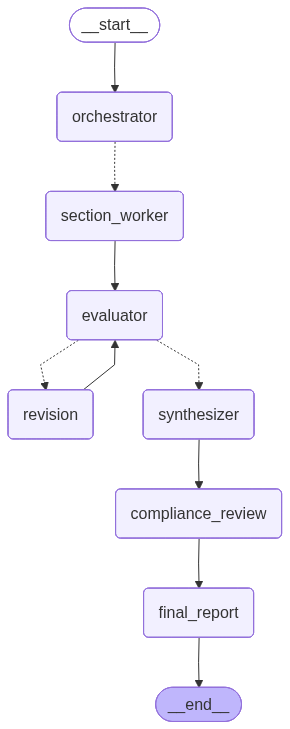

Graph visualization rendered.


In [20]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
    print("Graph visualization rendered.")
except Exception as e:
    # Fallback: print the Mermaid diagram source
    print("Could not render PNG. Mermaid diagram source:")
    print(graph.get_graph().draw_mermaid())

---

## Section 20: Run the FinCEN Report --- Main Demo

This is the primary demonstration. We generate a FinCEN BSA/AML quarterly compliance report for Q4 2025.

### What to Watch For

1. **Orchestrator** parses the FinCEN template (10 sections) and creates a plan
2. **Fan-out** dispatches 5+ parallel workers via `Send()`
3. **Workers** draft sections using real data from `DATA_SUMMARY`
4. **Evaluator** validates each section (watch for PASS/FAIL on 3 checks)
5. **Revision loop** fixes any failures (may iterate up to 3 times)
6. **Synthesizer** assembles the full report with executive summary
7. **HITL interrupt** pauses for compliance officer review

In [ ]:
# =====================================================================
# STEP 1: Invoke the graph for FinCEN report
# =====================================================================

thread_config = {"configurable": {"thread_id": "fincen-q4-2025"}}

initial_state = {
    "regulator": "FinCEN",
    "quarter": "Q4 2025",
    "template": fincen_template,
    "section_plan": [],
    "section_drafts": [],
    "evaluation_results": [],
    "sections_needing_revision": [],
    "iteration_count": 0,
    "approved_sections": [],
    "executive_summary": "",
    "full_report": "",
    "compliance_officer_notes": "",
    "hitl_approved": False,
    "acknowledged_warnings": [],
    "unresolved_sections": [],
    "final_report": "",
}

print("Starting FinCEN BSA/AML report generation...")
print(f"Regulator: FinCEN")
print(f"Quarter:   Q4 2025")
print(f"Template:  {len(fincen_template):,} chars, ~10 sections")
print()

start_time = time.time()

try:
    for event in graph.stream(initial_state, config=thread_config, stream_mode="updates"):
        for node_name, node_output in event.items():
            elapsed = time.time() - start_time
            print(f"\n[{elapsed:.1f}s] Node completed: {node_name}")
except TypeError as e:
    # Known benign post-interrupt serialization artifact. State is safe.
    if "msgpack serializable" in str(e) and "Send" in str(e):
        print(f"\n(Known msgpack/Send artifact after HITL pause --- state is intact.)")
    else:
        raise

elapsed = time.time() - start_time
print(f"\n{'='*60}")
print(f"Graph paused at HITL interrupt after {elapsed:.1f} seconds")
print(f"{'='*60}")


Starting FinCEN BSA/AML report generation...
Regulator: FinCEN
Quarter:   Q4 2025
Template:  5,406 chars, ~10 sections


ORCHESTRATOR: Planning FinCEN report for Q4 2025

Planned 8 sections:
  1. [AML] Section 1: AML Transaction Monitoring
     Data: ['aml_monitoring', 'institution'] | Ref: 31 CFR 1020.210
  2. [SAR] Section 2: Suspicious Activity Reporting (SAR)
     Data: ['sar_filings', 'aml_monitoring', 'institution'] | Ref: 31 CFR 1020.320
  3. [AML] Section 3: Currency Transaction Reporting (CTR)
     Data: ['aml_monitoring', 'institution'] | Ref: 31 CFR 1020.310
  4. [KYC] Section 4: Customer Due Diligence (CDD)
     Data: ['kyc_cdd', 'risk_assessment', 'institution'] | Ref: 31 CFR 1020.220
  5. [RISK] Section 5: Risk Assessment
     Data: ['risk_assessment', 'aml_monitoring', 'kyc_cdd'] | Ref: 31 CFR 1020.210
  6. [REMEDIATION] Section 6: Internal Controls and Audit
     Data: ['remediation', 'aml_monitoring', 'kyc_cdd'] | Ref: 31 CFR 1020.210
  7. [REMEDIATION] Section 7: Prio

In [22]:
current_state = graph.get_state(thread_config)

drafts = current_state.values.get('section_drafts', [])
print(f"Number of successfully completed drafts: {len(drafts)}")

if drafts:
    print("Successfully completed sections:")
    for d in drafts:
        print(f" - {d['section_name']}")

print("\nPending tasks (nodes that were running or are next):")
print(current_state.next)


Number of successfully completed drafts: 8
Successfully completed sections:
 - Section 1: AML Transaction Monitoring
 - Section 2: Suspicious Activity Reporting (SAR)
 - Section 3: Currency Transaction Reporting (CTR)
 - Section 4: Customer Due Diligence (CDD)
 - Section 5: Risk Assessment
 - Section 6: Internal Controls and Audit
 - Section 7: Prior Findings Remediation
 - Section 8: Regulatory Changes and Adaptations

Pending tasks (nodes that were running or are next):
('compliance_review',)


In [23]:
current_state = graph.get_state({"configurable": {"thread_id": "fincen-q4-2025"}})
report_content = current_state.values.get("full_report", "Report not found or not yet generated.")
print(report_content)

# FinCEN Quarterly Compliance Report
## Q4 2025 | MidwestBank
## Prepared: 2026-04-19

---

## Executive Summary

Executive Summary – Q4 2025 FinCEN Compliance Report for MidwestBank

MidwestBank, with total assets of $8 billion, 500 employees, and 42 branches, continues to demonstrate a robust commitment to anti-money laundering (AML) and Bank Secrecy Act (BSA) compliance. During Q4 2025, the institution processed 50,000 transactions totaling approximately $311.3 million. Suspicious transaction reporting remains vigilant, with 1,053 suspicious transactions identified, representing 2.11% of total transactions and involving $5.2 million. Currency Transaction Reporting (CTR) identified 4,347 transactions exceeding the $10,000 threshold, reflecting ongoing adherence to regulatory thresholds.

Suspicious Activity Report (SAR) filings totaled 250, involving $123 million. Notable activity types include round dollar amounts, currency exchange patterns, unusual wire transfers, and trade-based 

### Step 2: Inspect the State Before HITL Review

Before the compliance officer decides, let us inspect the current graph state to see what was produced.

In [24]:
# =====================================================================
# STEP 2: Inspect the interrupted state
# =====================================================================

current_state = graph.get_state(thread_config)

print("=" * 60)
print("CURRENT GRAPH STATE (paused at HITL)")
print("=" * 60)

state_vals = current_state.values

print(f"\nRegulator:        {state_vals.get('regulator')}")
print(f"Quarter:          {state_vals.get('quarter')}")
print(f"Sections planned: {len(state_vals.get('section_plan', []))}")
print(f"Sections drafted: {len(state_vals.get('section_drafts', []))}")
print(f"Sections approved:{len(state_vals.get('approved_sections', []))}")
print(f"Iterations used:  {state_vals.get('iteration_count', 0)}")
print(f"Report length:    {len(state_vals.get('full_report', '')):,} chars")

# Show the section plan
print(f"\n--- Section Plan ---")
for i, section in enumerate(state_vals.get("section_plan", []), 1):
    print(f"  {i}. [{section['worker_type'].upper()}] {section['section_name']}")

# Show evaluation results summary
print(f"\n--- Evaluation Results ---")
for result in state_vals.get("evaluation_results", []):
    status = "PASS" if result.get("overall_pass") else "FAIL"
    print(f"  [{status}] {result.get('section_name')}")

# Show executive summary preview
exec_summary = state_vals.get("executive_summary", "")
if exec_summary:
    print(f"\n--- Executive Summary Preview (first 500 chars) ---")
    print(exec_summary[:500])
    print("...")

CURRENT GRAPH STATE (paused at HITL)

Regulator:        FinCEN
Quarter:          Q4 2025
Sections planned: 8
Sections drafted: 8
Sections approved:8
Iterations used:  1
Report length:    29,366 chars

--- Section Plan ---
  1. [AML] Section 1: AML Transaction Monitoring
  2. [SAR] Section 2: Suspicious Activity Reporting (SAR)
  3. [AML] Section 3: Currency Transaction Reporting (CTR)
  4. [KYC] Section 4: Customer Due Diligence (CDD)
  5. [RISK] Section 5: Risk Assessment
  6. [REMEDIATION] Section 6: Internal Controls and Audit
  7. [REMEDIATION] Section 7: Prior Findings Remediation
  8. [RISK] Section 8: Regulatory Changes and Adaptations

--- Evaluation Results ---
  [PASS] Section 1: AML Transaction Monitoring
  [PASS] Section 2: Suspicious Activity Reporting (SAR)
  [PASS] Section 3: Currency Transaction Reporting (CTR)
  [PASS] Section 4: Customer Due Diligence (CDD)
  [PASS] Section 5: Risk Assessment
  [PASS] Section 6: Internal Controls and Audit
  [PASS] Section 7: Prior Fi

### Step 3: Compliance Officer Approves the Report

In a production system, this would be a web form or Slack notification. Here we simulate the compliance officer reviewing the executive summary and approving with notes.

We use `Command(resume={...})` to inject the officer's decision and restart the graph from the interrupt point.

In [ ]:
# =====================================================================
# STEP 3: Compliance officer approves the report
# =====================================================================
#
# Check current state to see if there are any unresolved sections to acknowledge
pre_resume_state = graph.get_state(thread_config)
unresolved = pre_resume_state.values.get("unresolved_sections", [])

print("Compliance officer reviewing report...")
if unresolved:
    print(f"!! {len(unresolved)} unresolved section(s) flagged: {unresolved}")
    print("Officer will acknowledge them to proceed.")
else:
    print("All sections passed evaluation.")
print("Decision: APPROVED with notes\n")

# Resume the graph with the officer's decision
for event in graph.stream(
    Command(resume={
        "approved": True,
        "notes": (
            "Report approved for submission. Minor note: ensure the SAR timeliness "
            "section explicitly references the 30-day initial filing deadline per "
            "31 CFR 1020.320(b)(3). Add a footnote about the Q3 2025 regulatory "
            "guidance update from FinCEN Advisory FIN-2025-A001."
        ),
        # Acknowledge whatever unresolved sections exist (if any).
        # In production, each name in this list would be reviewed individually
        # with justification notes per section.
        "acknowledged_warnings": unresolved,
    }),
    config=thread_config,
    stream_mode="updates",
):
    for node_name, node_output in event.items():
        print(f"Node completed: {node_name}")

print("\nFinCEN report generation complete!")


Compliance officer reviewing report...
All sections passed evaluation.
Decision: APPROVED with notes


HITL: Awaiting compliance officer review...
  Regulator: FinCEN
  Quarter:   Q4 2025
  Sections:  8 total, 8 approved, 0 unresolved
  Report:    29,366 chars

  >>> Graph PAUSED --- waiting for Command(resume=...) <<<

  Officer decision: APPROVED
  Officer notes: Report approved for submission. Minor note: ensure the SAR timeliness section explicitly references the 30-day initial filing deadline per 31 CFR 1020.320(b)(3). Add a footnote about the Q3 2025 regul
Node completed: compliance_review

FINAL REPORT: Assembling submission-ready document
  Status: APPROVED
  Final report length: 29,731 chars
Node completed: final_report

FinCEN report generation complete!


In [26]:
# =====================================================================
# STEP 4: Display the final report
# =====================================================================

final_state = graph.get_state(thread_config)
final_report = final_state.values.get("final_report", "")

print("=" * 60)
print("FINAL FINCEN REPORT")
print("=" * 60)
print(f"Length: {len(final_report):,} characters")
print(f"HITL Approved: {final_state.values.get('hitl_approved')}")
print(f"Officer Notes: {final_state.values.get('compliance_officer_notes', '')[:200]}")
print("\n--- Report Preview (first 2000 chars) ---\n")
print(final_report[:2000])
print("\n... [truncated for display] ...")

FINAL FINCEN REPORT
Length: 29,731 characters
HITL Approved: True
Officer Notes: Report approved for submission. Minor note: ensure the SAR timeliness section explicitly references the 30-day initial filing deadline per 31 CFR 1020.320(b)(3). Add a footnote about the Q3 2025 regul

--- Report Preview (first 2000 chars) ---

# FinCEN Quarterly Compliance Report
## Q4 2025 | MidwestBank
## Prepared: 2026-04-19

---

## Executive Summary

Executive Summary – Q4 2025 FinCEN Compliance Report for MidwestBank

MidwestBank, with total assets of $8 billion, 500 employees, and 42 branches, continues to demonstrate a robust commitment to anti-money laundering (AML) and Bank Secrecy Act (BSA) compliance. During Q4 2025, the institution processed 50,000 transactions totaling approximately $311.3 million. Suspicious transaction reporting remains vigilant, with 1,053 suspicious transactions identified, representing 2.11% of total transactions and involving $5.2 million. Currency Transaction Reportin

---

## Section 21: Run the OCC Report --- Template Adaptation Demo

Now we demonstrate that the **same system adapts to a different regulator's template**. The OCC template has a different structure (10 Parts vs. FinCEN's 10 Sections), different terminology ("Management Summary" vs. "Executive Summary"), and additional topics (consumer protection, cybersecurity, enterprise risk).

The orchestrator will:
- Parse the OCC template's unique structure
- Create a different section plan with different worker assignments
- Adapt the regulatory references to OCC-specific citations

In [27]:
# =====================================================================
# OCC REPORT --- different template, same system
# (Same msgpack/Send guard as the FinCEN run above.)
# =====================================================================

occ_config = {"configurable": {"thread_id": "occ-q4-2025"}}

occ_initial_state = {
    "regulator": "OCC",
    "quarter": "Q4 2025",
    "template": occ_template,
    "section_plan": [],
    "section_drafts": [],
    "evaluation_results": [],
    "sections_needing_revision": [],
    "iteration_count": 0,
    "approved_sections": [],
    "executive_summary": "",
    "full_report": "",
    "compliance_officer_notes": "",
    "hitl_approved": False,
    "acknowledged_warnings": [],
    "unresolved_sections": [],
    "final_report": "",
}

print("Starting OCC Safety & Soundness report generation...")
print(f"Template: {len(occ_template):,} chars, ~10 parts")
print()

start_time = time.time()

try:
    for event in graph.stream(occ_initial_state, config=occ_config, stream_mode="updates"):
        for node_name, node_output in event.items():
            elapsed = time.time() - start_time
            print(f"[{elapsed:.1f}s] Node completed: {node_name}")
except TypeError as e:
    if "msgpack serializable" in str(e) and "Send" in str(e):
        print(f"\n(Known msgpack/Send artifact after HITL pause --- state is intact.)")
    else:
        raise

elapsed = time.time() - start_time
print(f"\nGraph paused at HITL interrupt after {elapsed:.1f} seconds")


Starting OCC Safety & Soundness report generation...
Template: 5,530 chars, ~10 parts


ORCHESTRATOR: Planning OCC report for Q4 2025

Planned 14 sections:
  1. [RISK] Part I: Compliance Management System
     Data: ['institution', 'risk_assessment', 'remediation'] | Ref: 12 CFR Part 30 (OCC safety and soundness / governance expectations)
  2. [AML] Part II.A: BSA/AML Program Assessment
     Data: ['aml_monitoring', 'risk_assessment', 'remediation'] | Ref: 31 CFR 1020.210 (BSA/AML program requirement)
  3. [AML] Part II.B: Transaction Monitoring
     Data: ['aml_monitoring'] | Ref: 31 CFR 1020.210 (AML program – monitoring controls)
  4. [KYC] Part II.C: Customer Identification Program (CIP)
     Data: ['kyc_cdd', 'institution'] | Ref: 31 CFR 1020.220 (Customer Identification Program requirements)
  5. [KYC] Part II.D: Customer Due Diligence (CDD)
     Data: ['kyc_cdd', 'aml_monitoring'] | Ref: 31 CFR 1020.210 (CDD and AML program expectations)
  6. [SAR] Part II.E: Suspicious Activity

In [28]:
# ---- OCC: Quick approve and display ----

pre_resume_state = graph.get_state(occ_config)
unresolved = pre_resume_state.values.get("unresolved_sections", [])

print("Compliance officer approving OCC report...\n")
if unresolved:
    print(f"!! {len(unresolved)} unresolved OCC section(s) flagged: {unresolved}")
    print("Officer will acknowledge them with specific notes.\n")

for event in graph.stream(
    Command(resume={
        "approved": True,
        "notes": (
            "OCC report approved. Ensure Part VII (Prior Examination Findings) "
            "addresses all outstanding MRAs. "
            + (f"Unresolved sections reviewed manually: {unresolved}." if unresolved else "")
        ),
        "acknowledged_warnings": unresolved,
    }),
    config=occ_config,
    stream_mode="updates",
):
    for node_name, _ in event.items():
        print(f"Node completed: {node_name}")

# Show OCC section plan for comparison
occ_state = graph.get_state(occ_config)
print(f"\n--- OCC Section Plan (compare with FinCEN above) ---")
for i, section in enumerate(occ_state.values.get("section_plan", []), 1):
    print(f"  {i}. [{section['worker_type'].upper()}] {section['section_name']}")

occ_report = occ_state.values.get("final_report", "")
print(f"\nOCC report length: {len(occ_report):,} chars")
print(f"\n--- OCC Report Preview (first 1000 chars) ---")
print(occ_report[:1000])
print("\n... [truncated] ...")


Compliance officer approving OCC report...


HITL: Awaiting compliance officer review...
  Regulator: OCC
  Quarter:   Q4 2025
  Sections:  14 total, 14 approved, 0 unresolved
  Report:    52,664 chars

  >>> Graph PAUSED --- waiting for Command(resume=...) <<<

  Officer decision: APPROVED
  Officer notes: OCC report approved. Ensure Part VII (Prior Examination Findings) addresses all outstanding MRAs. 
Node completed: compliance_review

FINAL REPORT: Assembling submission-ready document
  Status: APPROVED
  Final report length: 52,870 chars
Node completed: final_report

--- OCC Section Plan (compare with FinCEN above) ---
  1. [RISK] Part I: Compliance Management System
  2. [AML] Part II.A: BSA/AML Program Assessment
  3. [AML] Part II.B: Transaction Monitoring
  4. [KYC] Part II.C: Customer Identification Program (CIP)
  5. [KYC] Part II.D: Customer Due Diligence (CDD)
  6. [SAR] Part II.E: Suspicious Activity Reporting
  7. [RISK] Part III: Consumer Protection Compliance
  8. [RIS

---

## Section 22: Time Travel Demo --- Checkpoint History

One of the most powerful features of LangGraph's checkpointing is **time travel**: the ability to inspect past states of the graph. This is invaluable for:

- **Auditing:** Regulators may ask "show me the intermediate drafts before the evaluator revised them"
- **Debugging:** If a report has an issue, you can trace it back to the specific worker and iteration
- **Compliance documentation:** Maintaining a complete chain of custody for the report generation process

Let us explore the FinCEN report's checkpoint history.

In [29]:
# =====================================================================
# TIME TRAVEL: Inspect checkpoint history for the FinCEN report
# =====================================================================

print("=" * 60)
print("TIME TRAVEL: FinCEN Report Checkpoint History")
print("=" * 60)

# Get all state history entries
history = list(graph.get_state_history(thread_config))

print(f"\nTotal checkpoints: {len(history)}")
print(f"\n{'Step':<6} {'Node(s) Next':<30} {'Sections Drafted':<20} {'Iterations':<12} {'Report Len'}")
print("-" * 90)

for i, snapshot in enumerate(history):
    vals = snapshot.values
    next_nodes = [t[0] if isinstance(t, tuple) else str(t) for t in (snapshot.next or [])]
    next_str = ", ".join(next_nodes) if next_nodes else "(terminal)"
    drafts = len(vals.get("section_drafts", []))
    iters = vals.get("iteration_count", 0)
    report_len = len(vals.get("full_report", ""))

    print(f"{i:<6} {next_str:<30} {drafts:<20} {iters:<12} {report_len:,}")

print(f"\nYou can replay from any checkpoint by using graph.get_state_history()")
print("and passing a specific checkpoint's config to graph.invoke().")

TIME TRAVEL: FinCEN Report Checkpoint History

Total checkpoints: 8

Step   Node(s) Next                   Sections Drafted     Iterations   Report Len
------------------------------------------------------------------------------------------
0      (terminal)                     8                    1            29,366
1      final_report                   8                    1            29,366
2      compliance_review              8                    1            29,366
3      synthesizer                    8                    1            0
4      evaluator                      8                    0            0
5      section_worker, section_worker, section_worker, section_worker, section_worker, section_worker, section_worker, section_worker 0                    0            0
6      orchestrator                   0                    0            0
7      __start__                      0                    0            0

You can replay from any checkpoint by using graph.get

---

## Section 23: Multi-Model Comparison (Bonus)

Let us compare how different models handle the same section-writing task. We will draft a single AML section using both `gpt-5-mini` and `gpt-4.1-mini` and compare the results.

This helps teams make informed decisions about model selection for different roles in their agentic pipelines.

In [30]:
# =====================================================================
# MULTI-MODEL COMPARISON: Same section, different models
# =====================================================================

comparison_section = {
    "section_name": "AML Transaction Monitoring",
    "description": "Overview of transaction monitoring system performance, alert statistics, and AML program effectiveness.",
    "data_sources": ["aml_monitoring"],
    "worker_type": "aml",
    "regulatory_reference": "31 CFR 1020.210",
}

comparison_messages = [
    SystemMessage(content=WORKER_PROMPTS["aml"]),
    HumanMessage(content=f"""Draft the AML Transaction Monitoring section for a FinCEN quarterly report (Q4 2025).

DATA:
{json.dumps(DATA_SUMMARY['aml_monitoring'], indent=2)}

Keep it concise (200-300 words). Return a SectionDraft.""")
]

print("Comparing models on AML Transaction Monitoring section...\n")

# Model 1: gpt-4.1-mini (worker model)
start = time.time()
llm_41mini = ChatOpenAI(model="gpt-4.1-mini", temperature=0.2)
result_41 = llm_41mini.with_structured_output(SectionDraft, method="function_calling").invoke(comparison_messages)
time_41 = time.time() - start

# Model 2: gpt-5-mini (reasoning model)
start = time.time()
llm_5mini = ChatOpenAI(model="gpt-5-mini")
result_5 = llm_5mini.with_structured_output(SectionDraft, method="function_calling").invoke(comparison_messages)
time_5 = time.time() - start

print(f"{'Metric':<30} {'gpt-4.1-mini':<20} {'gpt-5-mini':<20}")
print("-" * 70)
print(f"{'Latency':<30} {time_41:.2f}s{'':<14} {time_5:.2f}s")
print(f"{'Content length':<30} {len(result_41.content):<20} {len(result_5.content):<20}")
print(f"{'Key metrics count':<30} {len(result_41.key_metrics):<20} {len(result_5.key_metrics):<20}")
print(f"{'Confidence':<30} {result_41.confidence:<20.2f} {result_5.confidence:<20.2f}")
print(f"{'Data citations':<30} {len(result_41.data_citations):<20} {len(result_5.data_citations):<20}")

print(f"\n--- gpt-4.1-mini output (first 400 chars) ---")
print(result_41.content[:400])
print(f"\n--- gpt-5-mini output (first 400 chars) ---")
print(result_5.content[:400])

print(f"\n--- Takeaway ---")
print("gpt-4.1-mini: Faster, cost-effective, good for templated writing tasks.")
print("gpt-5-mini:   Stronger reasoning, better for planning and evaluation tasks.")
print("Our architecture uses each model where it excels.")


Comparing models on AML Transaction Monitoring section...

Metric                         gpt-4.1-mini         gpt-5-mini          
----------------------------------------------------------------------
Latency                        3.36s               17.11s
Content length                 1248                 1204                
Key metrics count              0                    0                   
Confidence                     1.00                 0.90                
Data citations                 8                    13                  

--- gpt-4.1-mini output (first 400 chars) ---
During the fourth quarter of 2025, the bank processed a total of 50,000 transactions amounting to $311,260,070.15. Our BSA transaction monitoring system identified 1,053 suspicious transactions, representing 2.11% of the total transaction volume. These suspicious transactions involved a cumulative amount of $5,214,006.53. The monitoring system continues to focus on high-risk transaction types, wit

---

## Section 24: Full Pipeline Metrics

Let us summarize the key metrics from both report runs to demonstrate the system's capabilities.

In [31]:
# =====================================================================
# PIPELINE METRICS SUMMARY
# =====================================================================

fincen_state = graph.get_state(thread_config).values
occ_state_vals = graph.get_state(occ_config).values

print("=" * 70)
print("COMPLIANCE REPORT GENERATOR --- PIPELINE METRICS")
print("=" * 70)

print(f"\n{'Metric':<40} {'FinCEN Report':<20} {'OCC Report':<20}")
print("-" * 80)
print(f"{'Regulator':<40} {'FinCEN':<20} {'OCC':<20}")
print(f"{'Quarter':<40} {'Q4 2025':<20} {'Q4 2025':<20}")
print(f"{'Sections planned':<40} {len(fincen_state.get('section_plan', [])):<20} {len(occ_state_vals.get('section_plan', [])):<20}")
print(f"{'Sections drafted':<40} {len(fincen_state.get('section_drafts', [])):<20} {len(occ_state_vals.get('section_drafts', [])):<20}")
print(f"{'Evaluation iterations':<40} {fincen_state.get('iteration_count', 0):<20} {occ_state_vals.get('iteration_count', 0):<20}")
print(f"{'HITL approved':<40} {str(fincen_state.get('hitl_approved')):<20} {str(occ_state_vals.get('hitl_approved')):<20}")
print(f"{'Final report length':<40} {len(fincen_state.get('final_report', '')):>10,} chars   {len(occ_state_vals.get('final_report', '')):>10,} chars")

print(f"\n--- Evaluation Results (FinCEN) ---")
for r in fincen_state.get("evaluation_results", []):
    p = "PASS" if r.get("overall_pass") else "FAIL"
    print(f"  [{p}] {r.get('section_name')}")

print(f"\n--- Evaluation Results (OCC) ---")
for r in occ_state_vals.get("evaluation_results", []):
    p = "PASS" if r.get("overall_pass") else "FAIL"
    print(f"  [{p}] {r.get('section_name')}")

COMPLIANCE REPORT GENERATOR --- PIPELINE METRICS

Metric                                   FinCEN Report        OCC Report          
--------------------------------------------------------------------------------
Regulator                                FinCEN               OCC                 
Quarter                                  Q4 2025              Q4 2025             
Sections planned                         8                    14                  
Sections drafted                         8                    14                  
Evaluation iterations                    1                    2                   
HITL approved                            True                 True                
Final report length                          29,731 chars       52,870 chars

--- Evaluation Results (FinCEN) ---
  [PASS] Section 1: AML Transaction Monitoring
  [PASS] Section 2: Suspicious Activity Reporting (SAR)
  [PASS] Section 3: Currency Transaction Reporting (CTR)
  [PASS] Secti

---

## Section 26: Next Steps — Taking This Further

You have built a working multi-agent compliance report generator that demonstrates the orchestrator-worker, evaluator-optimizer, and human-in-the-loop patterns end-to-end, with real BFSI-shaped data and two distinct regulator templates. This is a solid portfolio project. Here are directions you can take it in to make it even stronger — tackle any one of these and the project starts to look like serious engineering work rather than a lab exercise.

**Hybrid validation.** Right now the numerical-accuracy check is an LLM asking another LLM. Replace it with a Python function that extracts every number from the draft, looks each one up in DATA_SUMMARY, and returns a deterministic pass/fail list. The LLM then only handles terminology and prose quality. This makes the pipeline cheaper, faster, and audit-friendly.

**Durable persistence.** Swap `MemorySaver` for `SqliteSaver` or `PostgresSaver`. Now your runs survive restarts, you can reload a report mid-review the next day, and you have a queryable audit log of every node's inputs and outputs.

**Structured audit trail.** Add a node after `final_report` that writes a JSON manifest (timestamp, officer identity, section approvals, acknowledged warnings, model versions, token counts) to disk or a database. This is what turns the notebook into something a compliance team could actually defend during an examination.

**Retry and fallback.** Wrap each LLM call in a retry decorator with exponential backoff. Add a fallback to a secondary model or provider when OpenAI returns 5xx or hits a rate limit. The pipeline should not fail because of a transient API hiccup.

**Deterministic PII layer.** The current regex redactor is good defense-in-depth but not the primary control. Build a preprocessing step that anonymizes DATA_SUMMARY before it reaches any LLM, using Microsoft Presidio or a similar named-entity-recognition library for stronger guarantees.

**Web UI for the HITL step.** Replace the `Command(resume=...)` notebook pattern with a small FastAPI + HTML page where the compliance officer can actually read the report, view unresolved warnings in a side panel, acknowledge them with per-section justification, and sign off with authentication. This is the piece that makes it feel like a product.

**Evaluation harness.** Build a small test suite that feeds known-correct and known-incorrect drafts into the evaluator and measures precision/recall of the three checks. You can use this to tune prompts with confidence instead of guessing whether a change helped.

**Cost and latency telemetry.** Instrument each node with token counts, latency, and model used, and emit a summary at the end. With the parallel evaluator a single run should be well under 5 minutes; being able to prove that with numbers is the kind of thing hiring managers remember.

Pick one. Ship it. Each of these is a weekend's work and each one measurably strengthens the project.


---
## 27. Conclusion & Key Takeaways

### What We Covered

| Concept | Takeaway |
|---|---|
| **Orchestrator-Worker pattern** | Orchestrator plans the work; workers execute one slice each. Best when slices are independent and unknown ahead of time. |
| **`Send` API** | How LangGraph dispatches a *list* of worker invocations in parallel from a single edge — the orchestrator returns `[Send('worker', state_for_slice_i), ...]`. |
| **Reducer for fan-in** | `Annotated[list[Draft], operator.add]` (or a custom merge-by-name reducer) tells LangGraph how to combine parallel worker outputs into the shared state. |
| **Evaluator-Optimizer pattern** | An LLM evaluates each worker's output against a rubric; failed sections loop back for revision, capped at N iterations. |
| **HITL via `interrupt()` mid-graph** | Pause for the compliance officer; the resume `Command` carries the officer's decision + acknowledged warnings. |
| **Hybrid validation** | LLM-as-judge for prose; deterministic Python for numbers — cheaper, faster, audit-friendly. |
| **Iteration cap** | Without `MAX_ITERATIONS = 3`, a strict evaluator can loop forever. Always bound the optimizer. |
| **Multi-regulator reuse** | One graph, three templates → three reports. The pattern's value is in re-using orchestration across compliance regimes. |

**Next Lab:** Lab 8.3 — Microsoft Agent Framework (autogen-agentchat 0.4) Hands-On 🤝


## 28. Stretch Exercise (Optional)

1. Replace the LLM-based numerical-accuracy check with a Python function that extracts every number from each draft and looks it up in `DATA_SUMMARY`. Compare cost, speed, and false-positive rate.
2. Swap `MemorySaver` for `SqliteSaver` so an interrupted run can be resumed the next day. Verify the FinCEN flow survives a kernel restart at the HITL pause.
3. Add a node after `final_report` that writes a JSON manifest (timestamp, officer identity, section approvals, acknowledged warnings, model versions) to disk — production audit trail.
4. Parallelize the **evaluator** the same way you parallelize workers: one `Send` per section. Measure throughput on a 10-section template.
5. Add a 4th regulator template (e.g., FRB Y-9C) and verify zero code changes are needed beyond the new template + minor worker prompt updates.
6. Wrap each LLM call in a retry decorator with exponential backoff + jitter, and log failures to LangSmith. Re-run with a flaky model and observe graceful degradation.


---

## Interview Preparation

The questions below mirror what client interviewers commonly ask about the topics in this lab. Use the hint to think through the answer first; use the sketch only to verify your reasoning.

---

**Q1. What is the Orchestrator-Worker pattern — when use it vs a supervisor?**

*Hint:* Both have a router; the difference is what the workers do.

*Answer sketch:* **Supervisor** routes ONE input to ONE specialist that does the full job. **Orchestrator-Worker** decomposes ONE input into N independent slices and dispatches a worker per slice (in parallel), then synthesizes. Use orchestrator-worker when (a) the work decomposes into roughly equal independent pieces and (b) the slice count is data-dependent (here: section count = template count). Use supervisor when slices aren't equal — different specialists, different skills.

---

**Q2. What is the Evaluator-Optimizer pattern — what problem does it solve?**

*Hint:* It's a quality-gating loop on top of any generator.

*Answer sketch:* An LLM (the evaluator) checks each generator output against a rubric (numerical accuracy, terminology compliance, cross-reference integrity here). Failed outputs loop back to the generator with the eval feedback for revision, up to a max iteration count. Solves the 'first-draft-isn't-good-enough' problem in regulated outputs without humans in the inner loop. Trade-off: each loop is a full generator round trip → 2-3× cost.

---

**Q3. How does the `Send` API enable dynamic worker spawning?**

*Hint:* An edge that returns a list, not a single next-node.

*Answer sketch:* Standard LangGraph edges return one next node. `Send('worker', payload_i)` is a directive: 'invoke the `worker` node with this specific payload'. Returning `[Send('worker', p1), Send('worker', p2), ...]` from an orchestrator dispatches all of them in parallel. The `Send` payload becomes that worker's input state — separate from the shared graph state. This is how you get N workers from a graph that doesn't know N at compile time.

---

**Q4. When does the evaluator decide a revision is needed — what's in the prompt?**

*Hint:* Look at the rubric structure.

*Answer sketch:* The evaluator prompt encodes a multi-check rubric: (1) numerical accuracy — every number in the draft is in `DATA_SUMMARY`, (2) terminology compliance — uses regulator-specific phrasing, (3) cross-reference integrity — section references resolve. Output is structured (`overall_pass: bool`, `issues: list[str]`). If `overall_pass=False`, the section's name is added to `sections_needing_revision` and `iteration_count` is incremented. If the count exceeds the cap, synthesis proceeds with the section flagged as unresolved.

---

**Q5. How is HITL integrated mid-graph — what's the user experience?**

*Hint:* `interrupt()` raises a special exception that the runtime catches and persists.

*Answer sketch:* Inside `compliance_officer_review`, calling `interrupt(payload)` pauses execution and saves the full graph state to the checkpointer. The caller's `graph.stream(...)` returns immediately with the interrupt payload. The user (compliance officer) inspects the report, then calls `graph.stream(Command(resume={'approved': True, 'notes': '...', 'acknowledged_warnings': [...]}), config)`. The graph rehydrates state, and `interrupt()` returns the resume payload. From the node's POV it's a single function call.

---

**Q6. How do you prevent infinite revise/evaluate loops?**

*Hint:* Counter + idempotent rubric.

*Answer sketch:* Two guards. (1) An explicit `MAX_ITERATIONS` constant — the evaluator skips sections in `approved_sections` and increments `iteration_count`; once the count hits the cap, synthesis runs with the unresolved section flagged. (2) An idempotent rubric — same input must produce same pass/fail, otherwise the same section can flip back and forth and never settle. Without both, a strict-but-flaky evaluator can loop until the API budget is exhausted.

---

**Q7. What's the trade-off: evaluator-as-LLM vs evaluator-as-rule?**

*Hint:* Recall vs precision vs cost.

*Answer sketch:* LLM evaluator: catches subjective issues (terminology, tone, regulatory phrasing) — high recall, lower precision (false positives), expensive (extra round trip per section per iteration). Rule evaluator: deterministic, cheap, audit-friendly, but only catches what you've coded — misses semantic issues. Production pattern: hybrid — Python rules for numbers/refs (deterministic), LLM for prose (subjective). This lab uses LLM-only as the simpler teaching version; the Stretch makes it hybrid.

---

**Q8. How would you parallelize the worker stage if section count is unknown ahead of time?**

*Hint:* That's exactly what `Send` was designed for.

*Answer sketch:* The orchestrator reads the template, generates a section plan as data (`list[SectionSpec]`), and `assign_workers` returns `[Send('worker', spec) for spec in section_plan]`. LangGraph dispatches all of them concurrently. Fan-in uses `Annotated[list[Draft], operator.add]` (or a custom merge-by-name reducer to handle revisions). The graph is compiled once; the parallel width is determined per-invocation by the orchestrator's plan.



# LangGraph vs CrewAI vs Microsoft Agent Framework (MAF)

| Dimension | **LangGraph** | **CrewAI** | **Microsoft Agent Framework (MAF)** |
|---|---|---|---|
| **Maintainer** | LangChain Inc. | CrewAI Inc. (independent) | Microsoft |
| **Maturity / Release** | Stable 1.0; mature, widely adopted | 44.6K+ GitHub stars, production-ready | 1.0 GA on April 3, 2026 — unifies AutoGen + Semantic Kernel into a single product |
| **Core Paradigm** | Graph-based state machine — state flows through nodes and edges | Role-based teams ("crew") of role-playing agents with role, goal, backstory | Unified runtime for agentic workflows; YAML-declarative agent definitions + code |
| **Mental Model** | "Nodes and edges, with explicit state transitions" | "Cast of human-like agents on a team" | "Enterprise agent runtime spanning .NET and Python" |
| **Languages** | Python, TypeScript | Python only | .NET and Python |
| **Multi-Agent Orchestration** | Explicit via graph topology; supervisor / hierarchical / cyclic | Sequential, hierarchical (manager delegates), consensual (agents vote) | Group chat, handoff, sequential, custom orchestration (inherited from AutoGen + SK patterns) |
| **State Management** | Built-in checkpointing, durable execution, fine-grained state schema | No built-in checkpointing; coarse error handling; communication mediated through task outputs | Native persistence + thread/state management with Azure integration |
| **Human-in-the-Loop** | First-class (interrupt / resume on graph nodes) | Limited / via task design | Built-in approval and intervention patterns |
| **Model Support** | Model-agnostic (any LLM provider) | Model-agnostic | Model-agnostic; deep tie-ins to Azure OpenAI / Foundry |
| **Protocol Support (MCP / A2A)** | MCP via LangChain ecosystem; A2A not native | A2A support added; MCP first-class | A2A, MCP, and AG-UI supported out of the box |
| **Observability** | LangSmith (trace-level visibility per node) | Built-in logs + integrates with LangFuse, AgentOps | Azure Monitor, Application Insights, OpenTelemetry |
| **Cloud / Enterprise Fit** | Cloud-agnostic; LangGraph Platform for hosted deployment | Cloud-agnostic | Best fit for .NET shops, deep Azure integration, Foundry Agent Service for managed hosting |
| **Learning Curve** | Steepest — verbose, requires state schema, nodes, edges, compilation | Easiest — prototype in ~20 lines | Moderate; YAML-first lowers code overhead but ecosystem is broad |
| **Control vs. Speed** | Most control, lowest speed-to-prototype | Fastest to prototype; less fine-grained control | Balanced; declarative for simple cases, code for complex |
| **Best For** | Complex, stateful, branching workflows; production systems needing fault tolerance, retries, and audit trails | Role-based collaboration (Researcher → Analyst → Writer); rapid prototyping; business workflow automation | Enterprise/regulated environments, M365 + Copilot integration, mixed .NET/Python teams, Azure-native deployments |
| **Weak Spots** | Verbose for simple flows; learning curve | Limited at scale; teams often migrate to LangGraph when they need production-grade state management | Younger as a unified product (post-merger churn); strongest value tied to Microsoft stack |
| **License** | MIT (open source) | MIT (open source) | MIT (open source) |

### Picking one for BFSI work
- **Auditable, regulated workflows with retries + HIL approvals** (e.g., dispute routing, KYC remediation, loan adjudication) → **LangGraph**
- **Role-based research/analysis crews** (e.g., credit memo drafting: Researcher → Risk Analyst → Reviewer) → **CrewAI**
- **Bank already on Azure / .NET / Microsoft 365** with compliance needs and Foundry tooling → **MAF**

A common production pattern is to **prototype in CrewAI**, then migrate the critical paths to **LangGraph** (or **MAF** if Azure-native) once state, observability, and recovery requirements harden.